In [2]:

import logging
from pathlib import Path

import numpy as np
import polars as pl
import pandas as pd
from scipy import stats
# from decimal import Decimal
from datetime import datetime, timezone

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go

from typing import Optional, Tuple



In [3]:
# ============================================================================
# [START] - Polars Display Configurations
# ============================================================================

pl.Config.set_tbl_rows(100)      # show up to 100 rows
pl.Config.set_tbl_cols(50)       # show up to 50 columns
# pl.Config.set_tbl_width_chars(0) # 0 = no width limit
pl.Config.set_tbl_hide_dataframe_shape(False)  # keep shape info

# [ DEFAULT DECIMAL DISPLAY ]
# # Option 1: Set display precision globally
# pl.Config.set_fmt_float("full")

# Option 2: Set specific decimal places
# pl.Config.set_float_precision(7)

# # Option 3: Check individual values
# print(result["price_decimal"][7])  # Will show: 0.0070995

# ============================================================================
# [END] - Polars Display Configurations
# ============================================================================

polars.config.Config

In [4]:

class AvailableDatasets:
    """Available Datasets, returns request ID"""

    FULL_YEAR_2024__CME_JPY_V: str = "GLBX-20251028-HAE9P7SP3U"
    FULL_YEAR_2023__CME_JPY_V: str = "GLBX-20251116-MJ5JKQA9A4"
    FULL_YEAR_2022__CME_JPY_V: str = "GLBX-20251115-DJHUGKSLWB"


In [5]:

# WORKING DIRECTORY
MAIN_DIR = Path("/Users/number6/Projects/Bimini/")

# HISTORICAL DATA
HISTORICAL_DATA = MAIN_DIR / "0_data" / "historical"

# IMPORT PATH
PARQUET_DIR = HISTORICAL_DATA / "parquet"

# EXPORT PATH
EXPORT_DIR = MAIN_DIR / "journal_results"


In [6]:


"""

?

"""



TICK_SIZE = 0.00001




# Convert START_DATE and END_DATE to nanosecond epochs (integers)
START_DATE_NS = int(
    datetime(
        year=2022,
        month=10,
        day=27,
        hour=8,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)

END_DATE_NS = int(
    datetime(
        year=2022,
        month=11,
        day=14,
        hour=18,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)


hrf_start_dt = datetime.fromtimestamp(START_DATE_NS / 1e9, tz=timezone.utc)
hrf_end_dt = datetime.fromtimestamp(END_DATE_NS / 1e9, tz=timezone.utc)

print("START_DATE_NS", hrf_start_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))
print("END_DATE_NS", hrf_end_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))


"""

Rolling average container

Container_Size > Search_Range

Thus only consider end time for each new interval of the rolling average that would be available in the time frame


"""



START_DATE_NS 2022-10-27 08:00:00 UTC
END_DATE_NS 2022-11-14 18:00:00 UTC


'\n\nRolling average container\n\nContainer_Size > Search_Range\n\nThus only consider end time for each new interval of the rolling average that would be available in the time frame\n\n\n'

In [7]:

BUCKET_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/2313_Nov_21_25/bucket/fixed/bucket_fixed_consolidated.parquet")

# Data files to glob for processing
BUCKET_DATA_GLOB = pl.scan_parquet(str(BUCKET_DIR))

# Schema? ...


In [8]:
VOLUME_BAR_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/2313_Nov_21_25/volumebar/raw/volumebar_raw_consolidated.parquet")

# Data files to glob for processing
VOLUME_BAR_DATA_GLOB = pl.scan_parquet(str(VOLUME_BAR_DIR))

# Schema? ...


In [9]:
"""

DATASET FILTERED FOR EVENT

VolumeBar, used for price plots(?)

"""


# event__vb_lf = (
#     VOLUME_BAR_DATA_GLOB
#     .filter(
#         (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
#         (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
#     )
#     .with_columns([
#         pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
#     ])
# ).collect()


'\n\nDATASET FILTERED FOR EVENT\n\nVolumeBar, used for price plots(?)\n\n'

In [10]:
def plot_price_with_metrics(
    main_df: pl.DataFrame,
    main_ts_col: str,
    main_col: str,
    metrics_df: pl.DataFrame,
    metrics_ts_col: str,
    metric_cols: list[str],
    metric_labels: Optional[list[str]] = None,
    main_range: Tuple[Optional[float], Optional[float]] = (None, None),
    metric_range: Tuple[Optional[float], Optional[float]] = (None, None),
    main_range_padding: Tuple[float, float] = (0.0, 0.0),
    metric_range_padding: Tuple[float, float] = (0.0, 0.0),
    title: str = "Main Series vs. Metrics",
    main_label: str = "Main Series",
    main_symbol: str = "",
    main_symbol_prefix: bool = True,
    main_decimal_places: Optional[int] = None,
    show_calculation_guides: bool = True,
    step_lines: bool = True,
    event_a_col: str = "",
    event_a_label: str = "Event A",
    event_b_col: str = "",
    event_b_label: str = "Event B",
    show_time_labels: bool = True,
    rotate_time_labels: Optional[float] = None,
    time_label_interval_hours: Optional[int] = None,
    time_label_format: str = 'auto',
    time_label_max_count: Optional[int] = None,
    figsize: Tuple[int, int] = (16, 10),
) -> Tuple[plt.Figure, Tuple[plt.Axes, plt.Axes]]:
    """
    Plot a main time series with 1-4 metric time series on a dual-axis chart.
    
    Parameters
    ----------
    main_df : pl.DataFrame
        DataFrame containing main series data with nanosecond epoch timestamps.
    main_ts_col : str
        Column name for main series timestamps (nanosecond epoch).
    main_col : str
        Column name for main series values.
    metrics_df : pl.DataFrame
        DataFrame containing metric data with shared timestamps.
    metrics_ts_col : str
        Column name for metric timestamps (nanosecond epoch).
    metric_cols : list[str]
        List of 1-4 column names for metrics to plot.
    metric_labels : list[str], optional
        Display labels for metrics. Defaults to column names.
    main_range : tuple[float | None, float | None]
        Y-axis range for main series: (min, max). Use (None, None) for auto-calculation.
    metric_range : tuple[float | None, float | None]
        Y-axis range for metrics: (min, max). Use (None, None) for auto-calculation.
    main_range_padding : tuple[float, float]
        Absolute padding to add to main range: (lower_bound, upper_bound).
    metric_range_padding : tuple[float, float]
        Absolute padding to add to metric range: (lower_bound, upper_bound).
    title : str
        Chart title.
    main_label : str
        Label for main series in legend.
    main_symbol : str
        Symbol to display with main axis values (e.g., "$", "€", "¥"). Empty string for no symbol.
    main_symbol_prefix : bool
        If True, symbol appears before value. If False, symbol appears after value.
    main_decimal_places : int, optional
        Number of decimal places for main axis. None for auto-determination.
    show_calculation_guides : bool
        Whether to show calculation point markers and vertical interval lines.
    step_lines : bool
        If True, draw step function (horizontal lines held constant).
        If False, draw thin lines connecting calculation points.
    event_a_col : str
        Column name for event A boolean flags. Empty string disables feature.
    event_a_label : str
        Legend label for event A regions.
    event_b_col : str
        Column name for event B boolean flags. Empty string disables feature.
    event_b_label : str
        Legend label for event B regions.
    show_time_labels : bool
        Whether to display time labels on X-axis.
    rotate_time_labels : float, optional
        Rotation angle for time labels in degrees. None uses 0° for horizontal.
        Common values: 0 (horizontal), 45 (diagonal), 90 (vertical).
    time_label_interval_hours : int, optional
        Interval between time labels in hours. None for auto-determination.
    time_label_format : str
        Format for time labels. Options: 'auto', 'time_only', 'date_only', 'full',
        or custom strftime format string (e.g., '%H:%M' or '%Y-%m-%d').
    time_label_max_count : int, optional
        Maximum number of time labels to display. Overrides interval if set.
    figsize : tuple[int, int]
        Figure dimensions.
    
    Returns
    -------
    tuple[plt.Figure, tuple[plt.Axes, plt.Axes]]
        Figure and (main_axis, metrics_axis) tuple.
        
    Notes
    -----
    Time label priority hierarchy:
    1. show_time_labels=False → No labels shown
    2. time_label_max_count → Determines interval to meet max count
    3. time_label_interval_hours → Uses specified interval
    4. Auto-determination → Based on data timespan
    """
    if not 1 <= len(metric_cols) <= 4:
        raise ValueError("metric_cols must contain 1 to 4 column names")
    
    if metric_labels is None:
        metric_labels = metric_cols
    
    if len(metric_labels) != len(metric_cols):
        raise ValueError("metric_labels must match length of metric_cols")
    
    # Apply Bloomberg theme
    plt.rcParams.update({
        'figure.facecolor': '#0a0e27',
        'axes.facecolor': '#0f1419',
        'axes.edgecolor': '#1e2332',
        'axes.labelcolor': '#b3b8c4',
        'axes.titlecolor': '#ffffff',
        'text.color': '#e8eaed',
        'xtick.color': '#7e8391',
        'ytick.color': '#7e8391',
        'grid.color': '#1e2332',
        'grid.linestyle': '--',
        'grid.linewidth': 0.5,
        'grid.alpha': 0.3,
        'figure.dpi': 150,
        'axes.grid': True,
        'axes.axisbelow': True,
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'lines.linewidth': 2.5,
    })
    
    # Metric color palette (up to 4 colors)
    metric_colors = ['#ffd93d', '#ff6b6b', '#a29bfe', '#4ecdc4']
    
    # Event colors
    event_a_color = '#4ecdc4'  # Bright cyan/blue
    event_b_color = '#ff6b9d'  # Bright purple-pink
    
    # Convert main series data
    main_df_plot = main_df.with_columns(
        pl.from_epoch(pl.col(main_ts_col), time_unit="ns").alias("_ts_dt")
    )
    main_pd = main_df_plot.select(["_ts_dt", main_col]).to_pandas()
    main_pd = main_pd.sort_values("_ts_dt")
    
    # Convert metrics data
    metrics_cols_to_select = ["_ts_dt", "start_ts_ns", "end_ts_ns"] + metric_cols
    if event_a_col:
        metrics_cols_to_select.append(event_a_col)
    if event_b_col:
        metrics_cols_to_select.append(event_b_col)
    
    metrics_df_plot = metrics_df.with_columns([
        pl.from_epoch(pl.col(metrics_ts_col), time_unit="ns").alias("_ts_dt"),
        pl.from_epoch(pl.col("start_ts_ns"), time_unit="ns").alias("_start_dt"),
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("_end_dt"),
    ])
    
    metrics_cols_to_select_final = ["_ts_dt", "_start_dt", "_end_dt"] + metric_cols
    if event_a_col:
        metrics_cols_to_select_final.append(event_a_col)
    if event_b_col:
        metrics_cols_to_select_final.append(event_b_col)
    
    metrics_pd = metrics_df_plot.select(metrics_cols_to_select_final).to_pandas()
    metrics_pd = metrics_pd.sort_values("_ts_dt")
    
    # Calculate data timespan for auto-formatting
    time_min = main_pd["_ts_dt"].min()
    time_max = main_pd["_ts_dt"].max()
    timespan_hours = (time_max - time_min).total_seconds() / 3600
    
    # Calculate main range if needed
    if main_range[0] is None or main_range[1] is None:
        main_min = main_pd[main_col].min()
        main_max = main_pd[main_col].max()
        main_range = (main_min, main_max)
    
    # Apply padding to main range
    final_main_min = main_range[0] - main_range_padding[0]
    final_main_max = main_range[1] + main_range_padding[1]
    
    # Calculate metric range if needed
    if metric_range[0] is None or metric_range[1] is None:
        all_metric_values = []
        for col in metric_cols:
            all_metric_values.extend(metrics_pd[col].values)
        metric_min = min(all_metric_values)
        metric_max = max(all_metric_values)
        metric_range = (metric_min, metric_max)
    
    # Apply padding to metric range
    final_metric_min = metric_range[0] - metric_range_padding[0]
    final_metric_max = metric_range[1] + metric_range_padding[1]
    
    # Auto-determine decimal places for main axis if not specified
    if main_decimal_places is None:
        main_data_range = main_range[1] - main_range[0]
        if main_data_range >= 100:
            main_decimal_places = 0
        elif main_data_range >= 10:
            main_decimal_places = 1
        elif main_data_range >= 1:
            main_decimal_places = 2
        elif main_data_range >= 0.1:
            main_decimal_places = 3
        elif main_data_range >= 0.01:
            main_decimal_places = 4
        else:
            main_decimal_places = 5
    
    # Build list of event time ranges where lines should be discontinuous
    event_ranges = []
    if event_a_col:
        event_a_rows = metrics_pd[metrics_pd[event_a_col] == True]
        for _, row in event_a_rows.iterrows():
            event_ranges.append((row["_start_dt"], row["_end_dt"]))
    if event_b_col:
        event_b_rows = metrics_pd[metrics_pd[event_b_col] == True]
        for _, row in event_b_rows.iterrows():
            event_ranges.append((row["_start_dt"], row["_end_dt"]))
    
    # Helper function to check if a timestamp is within any event range
    def is_in_event(timestamp):
        for start, end in event_ranges:
            if start <= timestamp <= end:
                return True
        return False
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Track if events are actually shown for legend
    event_a_shown = False
    event_b_shown = False
    
    # Draw event A regions (lowest z-order)
    if event_a_col:
        event_a_rows = metrics_pd[metrics_pd[event_a_col] == True]
        for _, row in event_a_rows.iterrows():
            ax1.axvspan(
                row["_start_dt"],
                row["_end_dt"],
                color=event_a_color,
                alpha=0.3,
                zorder=0
            )
            event_a_shown = True
    
    # Draw event B regions (lowest z-order)
    if event_b_col:
        event_b_rows = metrics_pd[metrics_pd[event_b_col] == True]
        for _, row in event_b_rows.iterrows():
            ax1.axvspan(
                row["_start_dt"],
                row["_end_dt"],
                color=event_b_color,
                alpha=0.3,
                zorder=0
            )
            event_b_shown = True
    
    # Left Y-axis: Main series (with discontinuities during events)
    if len(event_ranges) > 0:
        # Split main data into segments avoiding event periods
        current_segment_times = []
        current_segment_values = []
        
        for i, row in main_pd.iterrows():
            timestamp = row["_ts_dt"]
            value = row[main_col]
            
            if is_in_event(timestamp):
                # If we have accumulated data, plot it
                if len(current_segment_times) > 0:
                    ax1.plot(
                        current_segment_times,
                        current_segment_values,
                        color='#00d4aa',
                        linewidth=2.5,
                        zorder=2
                    )
                    current_segment_times = []
                    current_segment_values = []
            else:
                current_segment_times.append(timestamp)
                current_segment_values.append(value)
        
        # Plot any remaining segment
        if len(current_segment_times) > 0:
            ax1.plot(
                current_segment_times,
                current_segment_values,
                color='#00d4aa',
                linewidth=2.5,
                label=main_label,
                zorder=2
            )
    else:
        # No events, plot continuously
        ax1.plot(
            main_pd["_ts_dt"],
            main_pd[main_col],
            color='#00d4aa',
            linewidth=2.5,
            label=main_label,
            zorder=2
        )
    
    ax1.set_ylabel(main_label, fontsize=11, color='#00d4aa')
    ax1.tick_params(axis='y', labelcolor='#00d4aa')
    ax1.set_ylim(final_main_min, final_main_max)
    
    # Format main axis with symbol and decimal places
    def format_main_axis(x, p):
        formatted_value = f'{x:,.{main_decimal_places}f}'
        if main_symbol:
            if main_symbol_prefix:
                return f'{main_symbol}{formatted_value}'
            else:
                return f'{formatted_value}{main_symbol}'
        return formatted_value
    
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(format_main_axis))
    
    # Right Y-axis: Metrics
    ax2 = ax1.twinx()
    
    metric_times = metrics_pd["_ts_dt"].values
    main_end_time = main_pd["_ts_dt"].iloc[-1]
    
    legend_lines = []
    legend_labels = []
    
    for i, (col, label) in enumerate(zip(metric_cols, metric_labels)):
        color = metric_colors[i]
        metric_values = metrics_pd[col].values
        
        if step_lines:
            # Plot step function with discontinuities during events
            for j in range(len(metric_times) - 1):
                start_time = metric_times[j]
                end_time = metric_times[j + 1]
                value = metric_values[j]
                
                # Check if this segment overlaps with any event
                segment_in_event = False
                for event_start, event_end in event_ranges:
                    if not (end_time <= event_start or start_time >= event_end):
                        segment_in_event = True
                        break
                
                if not segment_in_event:
                    ax2.hlines(
                        value,
                        start_time,
                        end_time,
                        colors=color,
                        linewidth=2.0,
                        zorder=3
                    )
            
            # Extend last value to end of main data if not in event
            if len(metric_times) > 0:
                last_time = metric_times[-1]
                last_value = metric_values[-1]
                
                segment_in_event = False
                for event_start, event_end in event_ranges:
                    if not (main_end_time <= event_start or last_time >= event_end):
                        segment_in_event = True
                        break
                
                if not segment_in_event:
                    ax2.hlines(
                        last_value,
                        last_time,
                        main_end_time,
                        colors=color,
                        linewidth=2.0,
                        zorder=3
                    )
        else:
            # Plot thin lines with discontinuities during events
            if len(event_ranges) > 0:
                current_segment_times = []
                current_segment_values = []
                
                for j in range(len(metric_times)):
                    timestamp = metric_times[j]
                    value = metric_values[j]
                    
                    if is_in_event(timestamp):
                        # Plot accumulated segment
                        if len(current_segment_times) > 0:
                            ax2.plot(
                                current_segment_times,
                                current_segment_values,
                                color=color,
                                linewidth=1.0,
                                zorder=3
                            )
                            current_segment_times = []
                            current_segment_values = []
                    else:
                        current_segment_times.append(timestamp)
                        current_segment_values.append(value)
                
                # Plot remaining segment
                if len(current_segment_times) > 0:
                    ax2.plot(
                        current_segment_times,
                        current_segment_values,
                        color=color,
                        linewidth=1.0,
                        zorder=3
                    )
            else:
                # No events, plot continuously
                ax2.plot(
                    metric_times,
                    metric_values,
                    color=color,
                    linewidth=1.0,
                    zorder=3
                )
        
        # Add calculation point markers if enabled (always show, even during events)
        if show_calculation_guides:
            ax2.scatter(
                metric_times,
                metric_values,
                color=color,
                s=60,
                zorder=4,
                edgecolors='#ffffff',
                linewidths=1.0
            )
        
        # Build legend entry
        legend_lines.append(plt.Line2D([0], [0], color=color, linewidth=2.0 if step_lines else 1.0))
        legend_labels.append(label)
    
    # Add vertical calculation interval lines if enabled
    if show_calculation_guides:
        for ptime in metric_times:
            ax1.axvline(
                x=ptime,
                color="#ffffff",
                alpha=0.5,
                linestyle=':',
                linewidth=1.0,
                zorder=1
            )
    
    # Configure right Y-axis
    ax2.set_ylabel('Metric Value', fontsize=11, color='#ffd93d')
    ax2.tick_params(axis='y', labelcolor='#ffd93d')
    ax2.set_ylim(final_metric_min, final_metric_max)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
    
    # Add reference lines for metric range (only at meaningful boundaries)
    metric_data_range = metric_range[1] - metric_range[0]
    if abs(metric_data_range - 2.0) < 0.1:  # Close to -1 to 1 range
        ax2.axhline(y=-1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    elif abs(metric_data_range - 1.0) < 0.1:  # Close to 0 to 1 range
        ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=0.5, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    else:
        # For custom ranges, add reference at midpoint
        midpoint = (metric_range[0] + metric_range[1]) / 2
        ax2.axhline(y=metric_range[0], color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=midpoint, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=metric_range[1], color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    
    # Configure X-axis time labels
    if show_time_labels:
        # Determine format string
        if time_label_format == 'auto':
            if timespan_hours < 6:
                format_str = '%H:%M'
            elif timespan_hours < 48:
                format_str = '%H:%M\n%m/%d'
            elif timespan_hours < 168:  # 1 week
                format_str = '%m/%d\n%H:%M'
            else:
                format_str = '%m/%d'
        elif time_label_format == 'time_only':
            format_str = '%H:%M'
        elif time_label_format == 'date_only':
            format_str = '%m/%d'
        elif time_label_format == 'full':
            format_str = '%H:%M\n%m/%d'
        else:
            # Custom format string
            format_str = time_label_format
        
        # Determine interval
        if time_label_max_count is not None:
            # Calculate interval to meet max count constraint
            calculated_interval_hours = max(1, int(timespan_hours / time_label_max_count))
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=calculated_interval_hours))
        elif time_label_interval_hours is not None:
            # Use specified interval
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=time_label_interval_hours))
        else:
            # Auto-determine interval based on timespan
            if timespan_hours < 6:
                interval = 1
            elif timespan_hours < 24:
                interval = 3
            elif timespan_hours < 48:
                interval = 6
            elif timespan_hours < 168:
                interval = 12
            else:
                interval = 24
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=interval))
        
        # Set formatter
        ax1.xaxis.set_major_formatter(mdates.DateFormatter(format_str))
        
        # Apply rotation
        rotation_angle = rotate_time_labels if rotate_time_labels is not None else 0
        ha = 'right' if rotation_angle > 0 else 'center'
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=rotation_angle, ha=ha)
    else:
        # Hide time labels
        ax1.xaxis.set_major_formatter(plt.NullFormatter())
    
    # Title
    ax1.set_title(title, fontsize=16, weight='bold', color='#ffffff', pad=20)
    
    # Style spines
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.spines['left'].set_color('#00d4aa')
    ax1.spines['left'].set_linewidth(1.5)
    ax1.spines['bottom'].set_color('#1e2332')
    ax2.spines['right'].set_color('#ffd93d')
    ax2.spines['right'].set_linewidth(1.5)
    
    # Build complete legend
    main_line = plt.Line2D([0], [0], color='#00d4aa', linewidth=2.5)
    all_lines = [main_line] + legend_lines
    all_labels = [main_label] + legend_labels
    
    # Add event patches to legend if they were shown
    if event_a_shown:
        event_a_patch = plt.Rectangle((0, 0), 1, 1, fc=event_a_color, alpha=0.3)
        all_lines.append(event_a_patch)
        all_labels.append(event_a_label)
    
    if event_b_shown:
        event_b_patch = plt.Rectangle((0, 0), 1, 1, fc=event_b_color, alpha=0.3)
        all_lines.append(event_b_patch)
        all_labels.append(event_b_label)
    
    if show_calculation_guides:
        calc_marker = plt.Line2D(
            [0], [0],
            marker='o',
            color='#ffffff',
            linewidth=0,
            markersize=8,
            markerfacecolor='#ffd93d',
            markeredgecolor='#ffffff',
            markeredgewidth=1.0
        )
        interval_line = plt.Line2D(
            [0], [0],
            color='#ffffff',
            alpha=0.5,
            linestyle=':',
            linewidth=1.0
        )
        all_lines.extend([calc_marker, interval_line])
        all_labels.extend(['Calculation Point', 'Calculation Interval'])
    
    # Legend outside plot area
    ax1.legend(
        all_lines,
        all_labels,
        loc='upper left',
        bbox_to_anchor=(1.08, 1.0),
        framealpha=0.95,
        facecolor='#0f1419',
        edgecolor='#1e2332',
        fontsize=9
    )
    
    # Disable grid on secondary axis
    ax2.grid(False)
    
    plt.tight_layout()
    
    return fig, (ax1, ax2)

In [11]:
"""

Priority hierarchy for time labels:

show_time_labels=False → No labels displayed at all
time_label_max_count → Calculates interval to show exactly this many labels
time_label_interval_hours → Uses the specified hour interval
Auto-determination → Based on data timespan (default behavior)

Usage examples:

"""

# # Default auto behavior - no parameters needed
# fig, axes = plot_price_with_metrics(
#     main_df=vwap,
#     main_ts_col="ts_recv",
#     main_col="Price",
#     metrics_df=metrics_event,
#     metrics_ts_col="end_ts_ns",
#     metric_cols=["ratio"],
# )

# # Hide time labels completely
# fig, axes = plot_price_with_metrics(..., show_time_labels=False)

# # Show max 10 labels with 45° rotation
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_max_count=10,
#     rotate_time_labels=45,
# )

# # Manual interval: every 3 hours, time only, vertical text
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_interval_hours=3,
#     time_label_format='time_only',
#     rotate_time_labels=90,
# )

# # Custom format with no rotation
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_format='%Y-%m-%d %H:%M',
#     rotate_time_labels=0,
# )

'\n\nPriority hierarchy for time labels:\n\nshow_time_labels=False → No labels displayed at all\ntime_label_max_count → Calculates interval to show exactly this many labels\ntime_label_interval_hours → Uses the specified hour interval\nAuto-determination → Based on data timespan (default behavior)\n\nUsage examples:\n\n'

### Streak Logic

In [12]:
# Define the columns to create streaks for and their threshold
STREAK_COLUMNS = [
    "ecdf__normalized__active_imbalance_abs",
    "ecdf__normalized__passive_imbalance_abs",
    "ecdf__normalized__active_imbalance_signed",
    "ecdf__normalized__passive_imbalance_signed",
    "ecdf__normalized__divergence_buy_volume",
    "ecdf__normalized__divergence_sell_volume",
]

THRESHOLD = 0.8

# Create boolean threshold columns dynamically
threshold_columns = [
    (pl.col(col) >= THRESHOLD).alias(f"above_threshold__{col}")
    for col in STREAK_COLUMNS
]

# Create streak group columns dynamically
streak_group_columns = [
    (pl.col(f"above_threshold__{col}") != pl.col(f"above_threshold__{col}").shift(1).fill_null(False))
      .cum_sum()
      .alias(f"streak_group__{col}")
    for col in STREAK_COLUMNS
]

# Create streak count columns dynamically
streak_count_columns = [
    pl.when(pl.col(f"above_threshold__{col}"))
      .then(pl.col(f"above_threshold__{col}").cum_count().over(f"streak_group__{col}"))
      .otherwise(0)
      .alias(f"streak__{col}_above_{str(THRESHOLD).replace('.', '')}")
    for col in STREAK_COLUMNS
]

# Print final streak column names
print("Final streak column names:")
for col in STREAK_COLUMNS:
    print(f"  streak__{col}_above_{str(THRESHOLD).replace('.', '')}")

# Generate list of columns to drop
columns_to_drop = (
    [f"above_threshold__{col}" for col in STREAK_COLUMNS] +
    [f"streak_group__{col}" for col in STREAK_COLUMNS]
)


Final streak column names:
  streak__ecdf__normalized__active_imbalance_abs_above_08
  streak__ecdf__normalized__passive_imbalance_abs_above_08
  streak__ecdf__normalized__active_imbalance_signed_above_08
  streak__ecdf__normalized__passive_imbalance_signed_above_08
  streak__ecdf__normalized__divergence_buy_volume_above_08
  streak__ecdf__normalized__divergence_sell_volume_above_08


In [13]:
# Define the columns to create streaks for and their threshold
STREAK_COLUMNS2 = [
    "ecdf__normalized__active_imbalance_abs",
    "ecdf__normalized__passive_imbalance_abs",
    "ecdf__normalized__active_imbalance_signed",
    "ecdf__normalized__passive_imbalance_signed",
]

THRESHOLD = 0.8

# Create boolean threshold columns dynamically
threshold_columns2 = [
    (pl.col(col) >= THRESHOLD).alias(f"above_threshold__{col}")
    for col in STREAK_COLUMNS2
]

# Create streak group columns dynamically
streak_group_columns2 = [
    (pl.col(f"above_threshold__{col}") != pl.col(f"above_threshold__{col}").shift(1).fill_null(False))
      .cum_sum()
      .alias(f"streak_group__{col}")
    for col in STREAK_COLUMNS2
]

# Create streak count columns dynamically
streak_count_columns2 = [
    pl.when(pl.col(f"above_threshold__{col}"))
      .then(pl.col(f"above_threshold__{col}").cum_count().over(f"streak_group__{col}"))
      .otherwise(0)
      .alias(f"streak__{col}_above_{str(THRESHOLD).replace('.', '')}")
    for col in STREAK_COLUMNS2
]

# Print final streak column names
print("Final streak column names:")
for col in STREAK_COLUMNS2:
    print(f"  streak__{col}_above_{str(THRESHOLD).replace('.', '')}")

# Generate list of columns to drop
columns_to_drop2 = (
    [f"above_threshold__{col}" for col in STREAK_COLUMNS2] +
    [f"streak_group__{col}" for col in STREAK_COLUMNS2]
)


Final streak column names:
  streak__ecdf__normalized__active_imbalance_abs_above_08
  streak__ecdf__normalized__passive_imbalance_abs_above_08
  streak__ecdf__normalized__active_imbalance_signed_above_08
  streak__ecdf__normalized__passive_imbalance_signed_above_08


In [14]:

"""

Create metric

"""

ROLLING_WINDOW_SIZE: int = 10 #50 #250

rolling_metric = (
    BUCKET_DATA_GLOB
    # (1) [ SUM values over the ROLLING_WINDOW_SIZE ]
    .with_columns([

        # Summary Data
        pl.col("time_elapsed_ns_total").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("time_elapsed_ns_total_rolling"),
        pl.col("volume_total_sum").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__volume_total_sum"),

        # Absolute Value
        pl.col("active_imbalance_abs").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__active_imbalance_abs"),
        pl.col("passive_imbalance_abs").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__passive_imbalance_abs"),

        # Signed Value
        pl.col("active_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__active_imbalance_signed"),
        pl.col("passive_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__passive_imbalance_signed"),

        # Imbalance Divergence
        pl.col("divergence_buy_volume_bucket").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__divergence_buy_volume"),
        pl.col("divergence_sell_volume_bucket").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__divergence_sell_volume"),
        
    ])
    # (2) [ FILTER/REMOVE the first n rows that have incomplete windows ]
    .filter(

        # Absolute Value
        pl.col("sum__active_imbalance_abs").is_not_null(),
        pl.col("sum__passive_imbalance_abs").is_not_null(),

        # Signed Value
        pl.col("sum__active_imbalance_signed").is_not_null(),
        pl.col("sum__passive_imbalance_signed").is_not_null(),

        # Imbalance Divergence
        pl.col("sum__divergence_buy_volume").is_not_null(),
        pl.col("sum__divergence_sell_volume").is_not_null(),

    )
    .with_columns([

        # [ Normalize Imbalances with Volumes ]

        # Absolute Value
        (pl.col("sum__active_imbalance_abs") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_abs"),
        (pl.col("sum__passive_imbalance_abs") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("sum__active_imbalance_signed") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_signed"),
        (pl.col("sum__passive_imbalance_signed") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        (pl.col("sum__divergence_buy_volume") / pl.col("sum__volume_total_sum")).alias("normalized__divergence_buy_volume"),
        (pl.col("sum__divergence_sell_volume") / pl.col("sum__volume_total_sum")).alias("normalized__divergence_sell_volume"),

    ])
    .with_columns([

        # ( For "percentile" value 0-100 )
        # (pl.col("total_active_imbalance_signed").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_active_imbalance_signed"),

        # [ CDF Calculations]

        # Absolute Value
        (pl.col("normalized__active_imbalance_abs").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_abs"),
        (pl.col("normalized__passive_imbalance_abs").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("normalized__active_imbalance_signed").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_signed"),
        (pl.col("normalized__passive_imbalance_signed").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        (pl.col("normalized__divergence_buy_volume").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__divergence_buy_volume"),
        (pl.col("normalized__divergence_sell_volume").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__divergence_sell_volume"),


    ])
    
#     .with_columns([

#         # [ Delta of CDF (change from previous row) ]

#         # Absolute Value
#         (pl.col("ecdf__normalized__active_imbalance_abs") - pl.col("ecdf__normalized__active_imbalance_abs").shift(1)).alias("delta__ecdf__normalized__active_imbalance_abs"),
#         (pl.col("ecdf__normalized__passive_imbalance_abs") - pl.col("ecdf__normalized__passive_imbalance_abs").shift(1)).alias("delta__ecdf__normalized__passive_imbalance_abs"),

#         # Signed Value
#         (pl.col("ecdf__normalized__active_imbalance_signed") - pl.col("ecdf__normalized__active_imbalance_signed").shift(1)).alias("delta__ecdf__normalized__active_imbalance_signed"),
#         (pl.col("ecdf__normalized__passive_imbalance_signed") - pl.col("ecdf__normalized__passive_imbalance_signed").shift(1)).alias("delta__ecdf__normalized__passive_imbalance_signed"),

#         # Imbalance Divergence
#         (pl.col("ecdf__normalized__divergence_buy_volume") - pl.col("ecdf__normalized__divergence_buy_volume").shift(1)).alias("delta__ecdf__normalized__divergence_buy_volume"),
#         (pl.col("ecdf__normalized__divergence_sell_volume") - pl.col("ecdf__normalized__divergence_sell_volume").shift(1)).alias("delta__ecdf__normalized__divergence_sell_volume"),

#     ])
#     ##### filter nan?
#     .with_columns([

#         # [ Slope of CDF delta values over rolling window ]

#         # Absolute Value
#         pl.col("delta__ecdf__normalized__passive_imbalance_abs").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__passive_imbalance_abs"),
#         pl.col("delta__ecdf__normalized__active_imbalance_abs").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__active_imbalance_abs"),

#         # Signed Value
#         pl.col("delta__ecdf__normalized__active_imbalance_signed").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__active_imbalance_signed"),
#         pl.col("delta__ecdf__normalized__passive_imbalance_signed").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__passive_imbalance_signed"),

#         # Imbalance Divergence
#         pl.col("delta__ecdf__normalized__divergence_buy_volume").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__divergence_buy_volume"),
#         pl.col("delta__ecdf__normalized__divergence_sell_volume").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__divergence_sell_volume"),

#     ])
#     #### filter nan?
#     .with_columns(threshold_columns)
#     .with_columns(streak_group_columns)
#     .with_columns(streak_count_columns)
#     .drop(columns_to_drop)

)

### Artificial Buckets

In [15]:
BUCKET_SIZE__IN_VOLUME_BARS = 100


buckets_from_volume_bars = (
    
    VOLUME_BAR_DATA_GLOB
    .with_columns(
        bucket=pl.int_range(pl.len()) // BUCKET_SIZE__IN_VOLUME_BARS
    )
    .group_by("bucket").agg(
        volume_total_sum=pl.col("volume_total").sum(),

        passive_vwap=pl.col("passive_midprice").mean(),
        delta_passive_midprice_log_std=pl.col("delta_passive_midprice_log").std(),

        active_imbalance_signed=pl.col("active_imbalance_signed").sum(),
        passive_imbalance_signed=pl.col("passive_imbalance_signed").sum(),

        time_elapsed_ns_total=pl.col("time_elapsed_ns").sum(),
        start_ts_ns=pl.col("start_ts_ns").first(),
        end_ts_ns=pl.col("end_ts_ns").last(),

        contract_roll_any=pl.col("contract_roll").any(),
        gap_return_any=pl.col("gap_return").any(),

    )
    .with_columns(
        prev_passive_vwap=pl.col("passive_vwap").shift(1),
    )
    .filter([
        pl.col("prev_passive_vwap").is_not_null(),
    ])
    .with_columns(
        price_delta=(pl.col("passive_vwap") - pl.col("passive_vwap").shift(1)),
        pct_return=(pl.col("passive_vwap") - pl.col("passive_vwap").shift(1)) / pl.col("passive_vwap").shift(1),
        log_return=pl.col("passive_vwap").log() - pl.col("passive_vwap").shift(1).log(),
    )
    .sort("bucket")
    .drop("bucket")
    # .select([
    #     "delta_midpoint_vwap_log",
    #     "buy_vwap",
    #     "sell_vwap",
    #     "total_vwap",
    #     "spread",
    #     "prev_total_vwap",
    #     "total_vwap_change",
    #     "pct_return",
    #     "log_return"
    # ])

)

In [16]:
buckets_from_volume_bars.collect()

volume_total_sum,passive_vwap,delta_passive_midprice_log_std,active_imbalance_signed,passive_imbalance_signed,time_elapsed_ns_total,start_ts_ns,end_ts_ns,contract_roll_any,gap_return_any,prev_passive_vwap,price_delta,pct_return,log_return
u32,f64,f64,i64,f64,u64,u64,u64,bool,bool,f64,f64,f64,f64
15000,8.6799e6,0.000095,523,-1579.882688,28597896015336,1641164400077327978,1641193246537331823,false,true,6.6728e6,2.0071e6,0.300789,0.262971
15000,8686865.2,0.00009,1038,2152.609318,15176148483939,1641193246537331823,1641208448138065473,false,false,6.8118e6,1.8750e6,0.275263,0.243152
15000,8.6916e6,0.000114,76,-2062.296703,11770969806208,1641208448152229813,1641220341103456276,false,false,7.6708e6,1.0207e6,0.133066,0.124927
15000,8.6762e6,0.000094,578,113.036908,5253866159864,1641220341103456276,1641225627290560892,false,false,7.6544e6,1.0218e6,0.133491,0.125302
15000,8.6772e6,0.000076,-802,-349.612816,17885881187960,1641225627290923971,1641243580485081898,false,false,7.3185e6,1.3587e6,0.185648,0.17029
15000,8.6700e6,0.000091,70,-1367.281722,21276007870328,1641243580485081898,1641264989389089867,false,false,6.8819e6,1.7880e6,0.259816,0.230965
15000,8.6469e6,0.000113,-52,-1592.50015,8392531233217,1641264989403992027,1641273445465957884,false,false,7.2984e6,1.3485e6,0.18476,0.16954
15000,8.6414e6,0.00012,1174,-261.388976,17090252432112,1641273445465957884,1641290609543415834,false,false,6871259.6,1.7701e6,0.257615,0.229217
15000,8615868.3,0.000118,-794,-2945.669996,9046091391565,1641290609543540237,1641299699449752265,false,false,6.4491e6,2.1667e6,0.335971,0.289658


### Artificial Metric

In [17]:

"""

Create metric

"""




# Bucket Lookback Count
ROLLING_WINDOW_SIZE: int = 100 #50 #250

metric_from_artificial_buckets = (
    buckets_from_volume_bars
    # (1) [ SUM values over the ROLLING_WINDOW_SIZE ]
    .with_columns([

        # Summary Data
        pl.col("time_elapsed_ns_total").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("time_elapsed_ns_total_rolling"),
        pl.col("volume_total_sum").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__volume_total_sum"),
        pl.col("start_ts_ns"),
        pl.col("end_ts_ns"),

        # Sum of Completely Absolute Value (Seems Wrong)
        pl.col("active_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__active_imbalance_abs_wrong"),
        pl.col("passive_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__passive_imbalance_abs_wrong"),

        # Sum of Actual Absolute Value (Seems Right?)
        (pl.col("active_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE)).abs().alias("sum__active_imbalance_abs"),
        (pl.col("passive_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE)).abs().alias("sum__passive_imbalance_abs"),

        # Signed Values
        pl.col("active_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__active_imbalance_signed"),
        pl.col("passive_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__passive_imbalance_signed"),
        
    ])
    # (2) [ FILTER/REMOVE the first n rows that have incomplete windows ]
    .filter(

        # Sum of Completely Absolute Value (Seems Wrong)
        pl.col("sum__active_imbalance_abs_wrong").is_not_null(),
        pl.col("sum__passive_imbalance_abs_wrong").is_not_null(),

        # Sum of Actual Absolute Value (Seems Right?)
        pl.col("sum__active_imbalance_abs").is_not_null(),
        pl.col("sum__passive_imbalance_abs").is_not_null(),

        # Signed Value
        pl.col("sum__active_imbalance_signed").is_not_null(),
        pl.col("sum__passive_imbalance_signed").is_not_null(),

    )
    .with_columns([

        # [ Normalize Imbalances with Volumes ]

        # Sum of Completely Absolute Value (Seems Wrong)
        (pl.col("sum__active_imbalance_abs_wrong") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_abs_wrong"),
        (pl.col("sum__passive_imbalance_abs_wrong") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_abs_wrong"),

        # Sum of Actual Absolute Value (Seems Right?)
        (pl.col("sum__active_imbalance_abs") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_abs"),
        (pl.col("sum__passive_imbalance_abs") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("sum__active_imbalance_signed") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_signed"),
        (pl.col("sum__passive_imbalance_signed") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_signed"),

    ])
    .with_columns([

        # ( For "percentile" value 0-100 )
        # (pl.col("total_active_imbalance_signed").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_active_imbalance_signed"),

        # [ CDF Calculations]

        # Sum of Completely Absolute Value (Seems Wrong)
        (pl.col("normalized__active_imbalance_abs_wrong").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_abs_wrong"),
        (pl.col("normalized__passive_imbalance_abs_wrong").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_abs_wrong"),

        # Sum of Actual Absolute Value (Seems Right?)
        (pl.col("normalized__active_imbalance_abs").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_abs"),
        (pl.col("normalized__passive_imbalance_abs").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("normalized__active_imbalance_signed").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_signed"),
        (pl.col("normalized__passive_imbalance_signed").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_signed"),


    ])
    .with_columns([
        
        (pl.col("ecdf__normalized__active_imbalance_abs").log()).alias("ecdf__normalized__active_imbalance_abs_log"),
        (pl.col("ecdf__normalized__passive_imbalance_abs").log()).alias("ecdf__normalized__passive_imbalance_abs_log"),

    ])
    .with_columns([
        
        pl.col("ecdf__normalized__active_imbalance_abs_log").alias("ln_vpin"),

    ])
    .with_columns([

        # [ Delta of CDF (change from previous row) ]

        # Sum of Completely Absolute Value (Seems Wrong)
        (pl.col("ecdf__normalized__active_imbalance_abs_wrong") - pl.col("ecdf__normalized__active_imbalance_abs_wrong").shift(1)).alias("delta__ecdf__normalized__active_imbalance_abs_wrong"),
        (pl.col("ecdf__normalized__passive_imbalance_abs_wrong") - pl.col("ecdf__normalized__passive_imbalance_abs_wrong").shift(1)).alias("delta__ecdf__normalized__passive_imbalance_abs_wrong"),

        # Absolute Value
        (pl.col("ecdf__normalized__active_imbalance_abs") - pl.col("ecdf__normalized__active_imbalance_abs").shift(1)).alias("delta__ecdf__normalized__active_imbalance_abs"),
        (pl.col("ecdf__normalized__passive_imbalance_abs") - pl.col("ecdf__normalized__passive_imbalance_abs").shift(1)).alias("delta__ecdf__normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("ecdf__normalized__active_imbalance_signed") - pl.col("ecdf__normalized__active_imbalance_signed").shift(1)).alias("delta__ecdf__normalized__active_imbalance_signed"),
        (pl.col("ecdf__normalized__passive_imbalance_signed") - pl.col("ecdf__normalized__passive_imbalance_signed").shift(1)).alias("delta__ecdf__normalized__passive_imbalance_signed"),

        # # Imbalance Divergence
        # (pl.col("ecdf__normalized__divergence_buy_volume") - pl.col("ecdf__normalized__divergence_buy_volume").shift(1)).alias("delta__ecdf__normalized__divergence_buy_volume"),
        # (pl.col("ecdf__normalized__divergence_sell_volume") - pl.col("ecdf__normalized__divergence_sell_volume").shift(1)).alias("delta__ecdf__normalized__divergence_sell_volume"),

    ])
    # (2) [ FILTER/REMOVE the first n rows that have incomplete windows ]
    # .filter(

    #     # Sum of Completely Absolute Value (Seems Wrong)
    #     pl.col("delta__ecdf__normalized__active_imbalance_abs_wrong").is_not_null(),
    #     pl.col("delta__ecdf__normalized__passive_imbalance_abs_wrong").is_not_null(),

    #     # Sum of Actual Absolute Value (Seems Right?)
    #     pl.col("delta__ecdf__normalized__active_imbalance_abs").is_not_null(),
    #     pl.col("delta__ecdf__normalized__passive_imbalance_abs").is_not_null(),

    #     # Signed Value
    #     pl.col("delta__ecdf__normalized__active_imbalance_signed").is_not_null(),
    #     pl.col("delta__ecdf__normalized__passive_imbalance_signed").is_not_null(),

    # )
    .with_columns([

        # [ Slope of CDF delta values over rolling window ]

        (pl.col("ecdf__normalized__active_imbalance_abs_wrong") - pl.col("ecdf__normalized__active_imbalance_abs_wrong").shift(1)).alias("delta__ecdf__normalized__active_imbalance_abs_wrong"),
        (pl.col("ecdf__normalized__passive_imbalance_abs_wrong") - pl.col("ecdf__normalized__passive_imbalance_abs_wrong").shift(1)).alias("delta__ecdf__normalized__passive_imbalance_abs_wrong"),

        # Sum of Completely Absolute Value (Seems Wrong)
        pl.col("delta__ecdf__normalized__active_imbalance_abs_wrong").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__active_imbalance_abs_wrong"),
        pl.col("delta__ecdf__normalized__passive_imbalance_abs_wrong").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__passive_imbalance_abs_wrong"),

        # Absolute Value
        pl.col("delta__ecdf__normalized__passive_imbalance_abs").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__passive_imbalance_abs"),
        pl.col("delta__ecdf__normalized__active_imbalance_abs").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__active_imbalance_abs"),

        # Signed Value
        pl.col("delta__ecdf__normalized__active_imbalance_signed").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__active_imbalance_signed"),
        pl.col("delta__ecdf__normalized__passive_imbalance_signed").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__passive_imbalance_signed"),

        # # Imbalance Divergence
        # pl.col("delta__ecdf__normalized__divergence_buy_volume").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__divergence_buy_volume"),
        # pl.col("delta__ecdf__normalized__divergence_sell_volume").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__divergence_sell_volume"),

    ])
    # .filter(

    #     # Sum of Completely Absolute Value (Seems Wrong)
    #     pl.col("delta__ecdf__normalized__active_imbalance_abs_wrong").is_not_null(),
    #     pl.col("delta__ecdf__normalized__passive_imbalance_abs_wrong").is_not_null(),

    #     # Sum of Actual Absolute Value (Seems Right?)
    #     pl.col("slope__delta__ecdf__normalized__active_imbalance_abs_wrong").is_not_null(),
    #     pl.col("slope__delta__ecdf__normalized__passive_imbalance_abs_wrong").is_not_null(),

    #     # Signed Value
    #     pl.col("slope__delta__ecdf__normalized__passive_imbalance_abs").is_not_null(),
    #     pl.col("slope__delta__ecdf__normalized__active_imbalance_abs").is_not_null(),

    #     # Signed Value
    #     pl.col("slope__delta__ecdf__normalized__active_imbalance_signed").is_not_null(),
    #     pl.col("slope__delta__ecdf__normalized__passive_imbalance_signed").is_not_null(),

    # )

)

In [18]:
with_streaks__metric_from_artificial_buckets = (

    metric_from_artificial_buckets
    .with_columns(threshold_columns2)
    .with_columns(streak_group_columns2)
    .with_columns(streak_count_columns2)
    .drop(columns_to_drop2)

)

In [19]:
rolling_metrics_event = (
    rolling_metric
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    .with_columns([
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
    ])
).collect()

print(rolling_metrics_event)


shape: (321, 362)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬───┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ id  ┆ buc ┆ num ┆ all ┆ bar ┆ con ┆ con ┆ lat ┆ sta ┆ end ┆ tim ┆ gap ┆ gap ┆ con ┆ con ┆ vol ┆ vol ┆ vol ┆ ord ┆ ord ┆ ord ┆ ord ┆ ord ┆ del ┆ del ┆ … ┆ pro ┆ nan ┆ nan ┆ nan ┆ pro ┆ tim ┆ sum ┆ sum ┆ sum ┆ sum ┆ sum ┆ sum ┆ sum ┆ nor ┆ nor ┆ nor ┆ nor ┆ nor ┆ nor ┆ ecd ┆ ecd ┆ ecd ┆ ecd ┆ ecd ┆ ecd │
│ --- ┆ ket ┆ _ba ┆ _ba ┆ _vo ┆ tra ┆ tra ┆ est ┆ rt_ ┆ _ts ┆ e_e ┆ _re ┆ _re ┆ tai ┆ tai ┆ ume ┆ ume ┆ ume ┆ er_ ┆ er_ ┆ er_ ┆ er_ ┆ er_ ┆ ta_ ┆ ta_ ┆   ┆ ces ┆ _co ┆ _co ┆ _co ┆ ces ┆ e_e ┆ __v ┆ __a ┆ __p ┆ __a ┆ __p ┆ __d ┆ __d ┆ mal ┆ mal ┆ mal ┆ mal ┆ mal ┆ mal ┆ f__ ┆ f__ ┆ f__ ┆ f__ ┆ f__ ┆ f__ │
│ u32 ┆ _ty ┆ rs  ┆ rs_ ┆ lum ┆ ct_ ┆ ct_ ┆ _in ┆ ts_ ┆ _ns ┆ la

In [20]:
# fig, (ax_price, ax_metrics) = plot_price_with_metrics(

#     main_df=rolling_metrics_event,
#     main_ts_col="end_ts_ns",
#     main_col="delta_passive_midprice_log_std", #"passive_midprice",
#     main_decimal_places=5,

#     metrics_df=rolling_metrics_event,
#     metrics_ts_col="end_ts_ns",
#     metric_cols=["streak__ecdf__normalized__active_imbalance_abs_above_08", "streak__ecdf__normalized__passive_imbalance_abs_above_08"],
#     metric_labels=["Active", "Passive"],
#     # metric_range=(0, 1),

#     title="6J (JPY/USD) Futures: Price vs. Order Flow Metrics",
#     main_label="Realized Vol.",


#     event_a_col="contract_roll_any",
#     event_a_label="CONTRACT ROLL",

#     event_b_col="gap_return_any",
#     event_b_label="MARKET CLOSED",

#     show_calculation_guides=False,
#     step_lines=False,
# )
# plt.show()

get bin sizes

map to conditional probabilities


In [21]:
# Get actual data range and create appropriate breaks
stats = rolling_metric.select([
    pl.col("delta_passive_midprice_log_std").min().alias("min"),
    pl.col("delta_passive_midprice_log_std").max().alias("max")
]).collect()

print(stats)

shape: (1, 2)
┌──────────┬──────────┐
│ min      ┆ max      │
│ ---      ┆ ---      │
│ f64      ┆ f64      │
╞══════════╪══════════╡
│ 0.000026 ┆ 0.002299 │
└──────────┴──────────┘


In [22]:
# Creates bins with approximately equal number of observations
quantiles_histogram = (
    rolling_metric
    .with_columns([
        pl.col("delta_passive_midprice_log_std").qcut(5, labels=[f"Q{i}" for i in range(1, 6)]).alias("bin")
    ])
    .group_by("bin")
    .agg([
        pl.len().alias("count"),
        pl.col("delta_passive_midprice_log_std").min().alias("bin_min"),
        pl.col("delta_passive_midprice_log_std").max().alias("bin_max")
    ])
    .sort("bin")
    .collect()
)

print(quantiles_histogram)

shape: (5, 4)
┌─────┬───────┬──────────┬──────────┐
│ bin ┆ count ┆ bin_min  ┆ bin_max  │
│ --- ┆ ---   ┆ ---      ┆ ---      │
│ cat ┆ u32   ┆ f64      ┆ f64      │
╞═════╪═══════╪══════════╪══════════╡
│ Q1  ┆ 3660  ┆ 0.000026 ┆ 0.000104 │
│ Q2  ┆ 3659  ┆ 0.000104 ┆ 0.000133 │
│ Q3  ┆ 3659  ┆ 0.000133 ┆ 0.000162 │
│ Q4  ┆ 3659  ┆ 0.000162 ┆ 0.000201 │
│ Q5  ┆ 3660  ┆ 0.000201 ┆ 0.002299 │
└─────┴───────┴──────────┴──────────┘


In [23]:

def create_bin_template(n_bins, bin_type="quantile"):
    """
    Create a template DataFrame showing the expected format for manual bins.
    
    Parameters:
    -----------
    n_bins : int
        Number of bins to create template for
    bin_type : str
        Type of bins ("quantile", "equal_width", or "custom")
    
    Returns:
    --------
    pl.DataFrame with columns: bin, bin_min, bin_max
    """
    if n_bins == 5:
        labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
    elif n_bins == 10:
        labels = ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6", "Q7", "Q8", "Q9", "Q10"]
    else:
        labels = [f"B{i+1}" for i in range(n_bins)]
    
    template = pl.DataFrame({
        "bin": labels,
        "bin_min": [0.0] * n_bins,  # Placeholder values
        "bin_max": [1.0] * n_bins   # Placeholder values
    })
    
    print(f"\nTemplate for {n_bins} bins ({bin_type}):")
    print("Replace bin_min and bin_max with your actual values")
    print(template)
    
    return template



In [24]:

def create_automatic_bins(df, col, n_bins):
    """
    Create quantile bins automatically from data.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing the data
    col : str
        Column name to bin
    n_bins : int
        Number of quantile bins (5, 10, 15, 20, etc.)
    
    Returns:
    --------
    pl.DataFrame with columns: bin, bin_min, bin_max
    """
    # Generate quantile points
    quantiles = [i / n_bins for i in range(n_bins + 1)]
    
    # Compute quantile values
    breaks = [df[col].quantile(q) for q in quantiles]
    
    # Create bin labels
    if n_bins == 5:
        labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
    elif n_bins == 10:
        labels = ["Q1", "Q2", "Q3", "Q4", "Q5", "Q6", "Q7", "Q8", "Q9", "Q10"]
    else:
        labels = [f"B{i+1}" for i in range(n_bins)]
    
    # Create bins dataframe
    bins_df = pl.DataFrame({
        "bin": labels,
        "bin_min": breaks[:-1],
        "bin_max": breaks[1:]
    })
    
    return bins_df



In [25]:

def validate_bins(bins_df):
    """
    Validate that bins are correctly formatted.
    
    Parameters:
    -----------
    bins_df : pl.DataFrame
        Bins dataframe to validate
    
    Returns:
    --------
    bool : True if valid, raises error otherwise
    """
    # Check required columns
    required_cols = ["bin", "bin_min", "bin_max"]
    if not all(col in bins_df.columns for col in required_cols):
        raise ValueError(f"Bins must have columns: {required_cols}")
    
    # Check that bin_max > bin_min
    invalid = bins_df.filter(pl.col("bin_max") <= pl.col("bin_min"))
    if len(invalid) > 0:
        raise ValueError(f"Found bins where bin_max <= bin_min:\n{invalid}")
    
    # Check for gaps (bin_min[i+1] should equal bin_max[i] for continuous bins)
    # This is optional - commented out as bins might intentionally have gaps
    # for i in range(len(bins_df) - 1):
    #     if bins_df["bin_max"][i] != bins_df["bin_min"][i+1]:
    #         print(f"Warning: Gap detected between {bins_df['bin'][i]} and {bins_df['bin'][i+1]}")
    
    print(f"✓ Bins validated successfully ({len(bins_df)} bins)")
    return True

In [26]:
# Test 1: Create automatic bins
test_data = pl.DataFrame({
    "x": np.random.randn(10000) * 0.0001 + 0.0002,
    "y": np.random.randn(10000) * 0.0001 + 0.0002
})

print("Test 1: Automatic bins (quintiles)")
x_bins_5 = create_automatic_bins(test_data, "x", n_bins=5)
print(x_bins_5)
validate_bins(x_bins_5)

print("\nTest 2: Automatic bins (deciles)")
x_bins_10 = create_automatic_bins(test_data, "x", n_bins=10)
print(x_bins_10)
validate_bins(x_bins_10)

print("\nTest 3: Create manual template")
manual_template = create_bin_template(n_bins=5, bin_type="custom")

print("\nTest 4: Manual bins (example)")
manual_bins = pl.DataFrame({
    "bin": ["Q1", "Q2", "Q3", "Q4", "Q5"],
    "bin_min": [0.0, 0.0001, 0.0002, 0.0003, 0.0004],
    "bin_max": [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]
})
print(manual_bins)
validate_bins(manual_bins)

Test 1: Automatic bins (quintiles)
shape: (5, 3)
┌─────┬───────────┬──────────┐
│ bin ┆ bin_min   ┆ bin_max  │
│ --- ┆ ---       ┆ ---      │
│ str ┆ f64       ┆ f64      │
╞═════╪═══════════╪══════════╡
│ Q1  ┆ -0.000174 ┆ 0.000118 │
│ Q2  ┆ 0.000118  ┆ 0.000176 │
│ Q3  ┆ 0.000176  ┆ 0.000228 │
│ Q4  ┆ 0.000228  ┆ 0.000286 │
│ Q5  ┆ 0.000286  ┆ 0.000571 │
└─────┴───────────┴──────────┘
✓ Bins validated successfully (5 bins)

Test 2: Automatic bins (deciles)
shape: (10, 3)
┌─────┬───────────┬──────────┐
│ bin ┆ bin_min   ┆ bin_max  │
│ --- ┆ ---       ┆ ---      │
│ str ┆ f64       ┆ f64      │
╞═════╪═══════════╪══════════╡
│ Q1  ┆ -0.000174 ┆ 0.000074 │
│ Q2  ┆ 0.000074  ┆ 0.000118 │
│ Q3  ┆ 0.000118  ┆ 0.000149 │
│ Q4  ┆ 0.000149  ┆ 0.000176 │
│ Q5  ┆ 0.000176  ┆ 0.000202 │
│ Q6  ┆ 0.000202  ┆ 0.000228 │
│ Q7  ┆ 0.000228  ┆ 0.000254 │
│ Q8  ┆ 0.000254  ┆ 0.000286 │
│ Q9  ┆ 0.000286  ┆ 0.00033  │
│ Q10 ┆ 0.00033   ┆ 0.000571 │
└─────┴───────────┴──────────┘
✓ Bins validated successfu

True

In [27]:
def assign_to_bins(df, col, bins_df, bin_col_name):
    """
    Assign values in a column to bins.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing the data
    col : str
        Column name to bin
    bins_df : pl.DataFrame
        Bins with columns: bin, bin_min, bin_max
    bin_col_name : str
        Name for the new bin column
    
    Returns:
    --------
    pl.DataFrame with new bin column added
    """
    bin_labels = bins_df["bin"].to_list()
    bin_maxs = bins_df["bin_max"].to_list()
    
    # Build conditional expression
    # Assign to first bin where value <= bin_max
    expr = pl.when(pl.col(col) <= bin_maxs[0]).then(pl.lit(bin_labels[0]))
    
    for i in range(1, len(bin_labels) - 1):
        expr = expr.when(pl.col(col) <= bin_maxs[i]).then(pl.lit(bin_labels[i]))
    
    # Last bin catches all remaining values
    expr = expr.otherwise(pl.lit(bin_labels[-1]))
    
    return df.with_columns([expr.alias(bin_col_name)])



In [28]:

def verify_bin_assignment(df, col, bin_col, bins_df):
    """
    Verify that bin assignment worked correctly and show diagnostics.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame with assigned bins
    col : str
        Original column name
    bin_col : str
        Bin column name
    bins_df : pl.DataFrame
        Bins specification
    
    Returns:
    --------
    pl.DataFrame with bin assignment summary
    """
    print(f"\nBin Assignment Verification for '{col}' -> '{bin_col}':")
    print(f"Data range: [{df[col].min():.6f}, {df[col].max():.6f}]")
    print(f"Bin range:  [{bins_df['bin_min'].min():.6f}, {bins_df['bin_max'].max():.6f}]")
    
    # Count assignments per bin
    assignment_summary = (
        df.group_by(bin_col)
        .agg([
            pl.len().alias("count"),
            pl.col(col).min().alias("actual_min"),
            pl.col(col).max().alias("actual_max")
        ])
        .join(bins_df, left_on=bin_col, right_on="bin", how="left")
        .select([
            pl.col(bin_col).alias("bin"),
            "count",
            "bin_min",
            "bin_max",
            "actual_min",
            "actual_max"
        ])
        .sort("bin")
    )
    
    print("\nAssignment Summary:")
    print(assignment_summary)
    
    # Check for null assignments
    null_count = df[bin_col].null_count()
    if null_count > 0:
        print(f"\n⚠ Warning: {null_count} values not assigned to any bin")
    else:
        print(f"\n✓ All {len(df)} values assigned to bins")
    
    return assignment_summary

In [29]:
# Test 1: Assign data to automatic bins
test_data = pl.DataFrame({
    "x": np.random.randn(10000) * 0.0001 + 0.0002,
    "y": np.random.randn(10000) * 0.0001 + 0.0002
})

print("=" * 60)
print("Test 1: Assign X to quintile bins")
print("=" * 60)
x_bins_5 = create_automatic_bins(test_data, "x", n_bins=5)
test_with_x_bins = assign_to_bins(test_data, "x", x_bins_5, "x_bin")
verify_bin_assignment(test_with_x_bins, "x", "x_bin", x_bins_5)

print("\n" + "=" * 60)
print("Test 2: Assign Y to decile bins")
print("=" * 60)
y_bins_10 = create_automatic_bins(test_data, "y", n_bins=10)
test_with_both_bins = assign_to_bins(test_with_x_bins, "y", y_bins_10, "y_bin")
verify_bin_assignment(test_with_both_bins, "y", "y_bin", y_bins_10)

print("\n" + "=" * 60)
print("Test 3: Check final dataframe")
print("=" * 60)
print(test_with_both_bins.select(["x", "x_bin", "y", "y_bin"]).head(10))

print("\nBin distribution:")
print(test_with_both_bins.group_by(["x_bin", "y_bin"]).agg(pl.len().alias("count")).sort(["x_bin", "y_bin"]))

Test 1: Assign X to quintile bins

Bin Assignment Verification for 'x' -> 'x_bin':
Data range: [-0.000231, 0.000588]
Bin range:  [-0.000231, 0.000588]

Assignment Summary:
shape: (5, 6)
┌─────┬───────┬───────────┬──────────┬────────────┬────────────┐
│ bin ┆ count ┆ bin_min   ┆ bin_max  ┆ actual_min ┆ actual_max │
│ --- ┆ ---   ┆ ---       ┆ ---      ┆ ---        ┆ ---        │
│ str ┆ u32   ┆ f64       ┆ f64      ┆ f64        ┆ f64        │
╞═════╪═══════╪═══════════╪══════════╪════════════╪════════════╡
│ Q1  ┆ 2001  ┆ -0.000231 ┆ 0.000116 ┆ -0.000231  ┆ 0.000116   │
│ Q2  ┆ 2000  ┆ 0.000116  ┆ 0.000175 ┆ 0.000116   ┆ 0.000175   │
│ Q3  ┆ 1999  ┆ 0.000175  ┆ 0.000226 ┆ 0.000175   ┆ 0.000226   │
│ Q4  ┆ 2000  ┆ 0.000226  ┆ 0.000284 ┆ 0.000226   ┆ 0.000284   │
│ Q5  ┆ 2000  ┆ 0.000284  ┆ 0.000588 ┆ 0.000284   ┆ 0.000588   │
└─────┴───────┴───────────┴──────────┴────────────┴────────────┘

✓ All 10000 values assigned to bins

Test 2: Assign Y to decile bins

Bin Assignment Verification 

In [30]:
def calculate_forward_conditional(df, x_col, y_col, x_bins, y_bins):
    """
    Calculate P(Y_i | X_{i-1}) - forward conditional probability.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing the time series data
    x_col : str
        Column name for X variable
    y_col : str
        Column name for Y variable
    x_bins : pl.DataFrame
        Bins for X with columns: bin, bin_min, bin_max
    y_bins : pl.DataFrame
        Bins for Y with columns: bin, bin_min, bin_max
    
    Returns:
    --------
    pl.DataFrame with columns: x_bin, y_bin, joint_count, marginal_x_count, conditional_prob
    """
    # Create lagged X variable (X_{i-1})
    df_lagged = (

        df
        .with_columns([

            pl.col(x_col).shift(1).alias("x_lag")

        ])
        .filter([

            # Absolute Value
            pl.col("x_lag").is_not_null(),
            pl.col(y_col).is_not_null(),

        ])

    )
    
    print(f"After lagging and dropping nulls: {len(df_lagged)} observations")
    
    # Assign X_{i-1} to bins
    df_lagged = assign_to_bins(df_lagged, "x_lag", x_bins, "x_bin")
    
    # Assign Y_i to bins
    df_lagged = assign_to_bins(df_lagged, y_col, y_bins, "y_bin")
    
    # DEBUG: Check assigned data
    print(f"DEBUG: Rows after binning: {len(df_lagged)}")
    print(f"DEBUG: x_bin nulls: {df_lagged['x_bin'].null_count()}")
    print(f"DEBUG: y_bin nulls: {df_lagged['y_bin'].null_count()}")
    
    # Calculate joint counts: count(X_{i-1} = x, Y_i = y)
    joint_counts = (
        df_lagged
        .group_by(["x_bin", "y_bin"])
        .agg(pl.len().alias("joint_count"))
    )
    
    print(f"DEBUG: joint_counts shape: {joint_counts.shape}")
    print(f"DEBUG: joint_counts sample:\n{joint_counts.head()}")
    
    # Calculate marginal counts: count(X_{i-1} = x)
    marginal_x = (
        df_lagged
        .group_by("x_bin")
        .agg(pl.len().alias("marginal_x_count"))
    )
    
    print(f"DEBUG: marginal_x shape: {marginal_x.shape}")
    print(f"DEBUG: marginal_x:\n{marginal_x}")
    
    # Calculate conditional probabilities: P(Y_i = y | X_{i-1} = x)
    conditional_probs = (
        joint_counts
        .join(marginal_x, on="x_bin", how="left")
        .with_columns([
            (pl.col("joint_count") / pl.col("marginal_x_count")).alias("conditional_prob")
        ])
        .sort(["x_bin", "y_bin"])
    )
    
    print(f"DEBUG: conditional_probs shape: {conditional_probs.shape}")
    print(f"DEBUG: conditional_probs sample:\n{conditional_probs.head()}")
    
    return conditional_probs



In [31]:


def calculate_reverse_conditional(df, x_col, y_col, x_bins, y_bins):
    """
    Calculate P(X_{i-1} | Y_i) - reverse conditional probability.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing the time series data
    x_col : str
        Column name for X variable
    y_col : str
        Column name for Y variable
    x_bins : pl.DataFrame
        Bins for X with columns: bin, bin_min, bin_max
    y_bins : pl.DataFrame
        Bins for Y with columns: bin, bin_min, bin_max
    
    Returns:
    --------
    pl.DataFrame with columns: x_bin, y_bin, joint_count, marginal_y_count, conditional_prob
    """
    # Create lagged X variable (X_{i-1})

    df_lagged = (

        df
        .with_columns([

            pl.col(x_col).shift(1).alias("x_lag")

        ])
        .filter([

            # Absolute Value
            pl.col("x_lag").is_not_null(),
            pl.col(y_col).is_not_null(),

        ])

    )
    
    print(f"After lagging and dropping nulls: {len(df_lagged)} observations")
    
    # Assign X_{i-1} to bins
    df_lagged = assign_to_bins(df_lagged, "x_lag", x_bins, "x_bin")
    
    # Assign Y_i to bins
    df_lagged = assign_to_bins(df_lagged, y_col, y_bins, "y_bin")
    
    # Calculate joint counts: count(X_{i-1} = x, Y_i = y)
    joint_counts = (
        df_lagged
        .group_by(["x_bin", "y_bin"])
        .agg(pl.len().alias("joint_count"))
    )
    
    # Calculate marginal counts: count(Y_i = y)
    marginal_y = (
        df_lagged
        .group_by("y_bin")
        .agg(pl.len().alias("marginal_y_count"))
    )
    
    # Calculate conditional probabilities: P(X_{i-1} = x | Y_i = y)
    conditional_probs = (
        joint_counts
        .join(marginal_y, on="y_bin", how="left")
        .with_columns([
            (pl.col("joint_count") / pl.col("marginal_y_count")).alias("conditional_prob")
        ])
        .sort(["y_bin", "x_bin"])
    )
    
    return conditional_probs


In [32]:


def verify_conditional_probabilities(conditional_probs, prob_type="forward"):
    """
    Verify that conditional probabilities sum to 1.0 for each conditioning variable.
    
    Parameters:
    -----------
    conditional_probs : pl.DataFrame
        Conditional probability table
    prob_type : str
        "forward" for P(Y|X) or "reverse" for P(X|Y)
    """
    if prob_type == "forward":
        # For P(Y|X), sum over Y for each X should be 1.0
        grouping_col = "x_bin"
        print(f"\nVerifying P(Y | X): sum over Y for each X")
    else:
        # For P(X|Y), sum over X for each Y should be 1.0
        grouping_col = "y_bin"
        print(f"\nVerifying P(X | Y): sum over X for each Y")
    
    sums = (
        conditional_probs
        .group_by(grouping_col)
        .agg(pl.col("conditional_prob").sum().alias("prob_sum"))
        .sort(grouping_col)
    )
    
    print(sums)
    
    # Check if all sums are approximately 1.0
    max_deviation = (sums["prob_sum"] - 1.0).abs().max()
    if max_deviation < 1e-10:
        print(f"✓ All probabilities sum to 1.0 (max deviation: {max_deviation:.2e})")
    else:
        print(f"⚠ Warning: max deviation from 1.0 is {max_deviation:.6f}")
    
    return sums

In [33]:
# Create test data with time series structure
np.random.seed(42)
n = 10000
test_data = pl.DataFrame({
    "x": np.random.randn(n) * 0.0001 + 0.0002,
    "y": np.random.randn(n) * 0.0001 + 0.0002
})

# Create bins
x_bins_5 = create_automatic_bins(test_data, "x", n_bins=5)
y_bins_5 = create_automatic_bins(test_data, "y", n_bins=5)

print("=" * 60)
print("Test 1: Forward Conditional P(Y_i | X_{i-1})")
print("=" * 60)
forward_probs = calculate_forward_conditional(test_data, "x", "y", x_bins_5, y_bins_5)
print("\nForward Conditional Probabilities:")
print(forward_probs)
verify_conditional_probabilities(forward_probs, prob_type="forward")

print("\n" + "=" * 60)
print("Test 2: Reverse Conditional P(X_{i-1} | Y_i)")
print("=" * 60)
reverse_probs = calculate_reverse_conditional(test_data, "x", "y", x_bins_5, y_bins_5)
print("\nReverse Conditional Probabilities:")
print(reverse_probs)
verify_conditional_probabilities(reverse_probs, prob_type="reverse")

print("\n" + "=" * 60)
print("Test 3: Sample of probabilities")
print("=" * 60)
print("\nForward (first 10 rows):")
print(forward_probs.head(10))
print("\nReverse (first 10 rows):")
print(reverse_probs.head(10))

Test 1: Forward Conditional P(Y_i | X_{i-1})
After lagging and dropping nulls: 9999 observations
DEBUG: Rows after binning: 9999
DEBUG: x_bin nulls: 0
DEBUG: y_bin nulls: 0
DEBUG: joint_counts shape: (25, 3)
DEBUG: joint_counts sample:
shape: (5, 3)
┌───────┬───────┬─────────────┐
│ x_bin ┆ y_bin ┆ joint_count │
│ ---   ┆ ---   ┆ ---         │
│ str   ┆ str   ┆ u32         │
╞═══════╪═══════╪═════════════╡
│ Q5    ┆ Q3    ┆ 411         │
│ Q5    ┆ Q5    ┆ 420         │
│ Q5    ┆ Q4    ┆ 364         │
│ Q2    ┆ Q3    ┆ 413         │
│ Q2    ┆ Q5    ┆ 373         │
└───────┴───────┴─────────────┘
DEBUG: marginal_x shape: (5, 2)
DEBUG: marginal_x:
shape: (5, 2)
┌───────┬──────────────────┐
│ x_bin ┆ marginal_x_count │
│ ---   ┆ ---              │
│ str   ┆ u32              │
╞═══════╪══════════════════╡
│ Q4    ┆ 1999             │
│ Q2    ┆ 2000             │
│ Q5    ┆ 2000             │
│ Q3    ┆ 1999             │
│ Q1    ┆ 2001             │
└───────┴──────────────────┘
DEBUG: conditi

In [34]:
def create_conditional_matrix(conditional_probs, x_bins, y_bins, prob_type="forward"):
    """
    Convert conditional probabilities to matrix form.
    
    Parameters:
    -----------
    conditional_probs : pl.DataFrame
        Conditional probability table with x_bin, y_bin, conditional_prob columns
    x_bins : pl.DataFrame
        Bins for X
    y_bins : pl.DataFrame
        Bins for Y
    prob_type : str
        "forward" for P(Y|X) or "reverse" for P(X|Y)
    
    Returns:
    --------
    numpy array where:
        - forward: rows are X bins, columns are Y bins (each row sums to 1.0)
        - reverse: rows are Y bins, columns are X bins (each row sums to 1.0)
    """
    n_x = len(x_bins)
    n_y = len(y_bins)
    
    x_labels = x_bins["bin"].to_list()
    y_labels = y_bins["bin"].to_list()
    x_map = {label: i for i, label in enumerate(x_labels)}
    y_map = {label: i for i, label in enumerate(y_labels)}
    
    if prob_type == "forward":
        # P(Y|X): rows are X, columns are Y
        matrix = np.zeros((n_x, n_y))
        for row in conditional_probs.iter_rows(named=True):
            i = x_map[row["x_bin"]]
            j = y_map[row["y_bin"]]
            matrix[i, j] = row["conditional_prob"]
        row_labels = x_labels
        col_labels = y_labels
    else:
        # P(X|Y): rows are Y, columns are X
        matrix = np.zeros((n_y, n_x))
        for row in conditional_probs.iter_rows(named=True):
            i = y_map[row["y_bin"]]
            j = x_map[row["x_bin"]]
            matrix[i, j] = row["conditional_prob"]
        row_labels = y_labels
        col_labels = x_labels
    
    return matrix, row_labels, col_labels



In [35]:

def print_conditional_matrix(matrix, row_labels, col_labels, title="Conditional Probability Matrix"):
    """
    Pretty print conditional probability matrix.
    
    Parameters:
    -----------
    matrix : numpy array
        Conditional probability matrix
    row_labels : list
        Labels for rows
    col_labels : list
        Labels for columns
    title : str
        Title for the matrix
    """
    print(f"\n{title}")
    print("=" * 80)
    
    # Print column headers
    header = "     " + "".join(f"{col:>8}" for col in col_labels)
    print(header)
    print("-" * len(header))
    
    # Print rows
    for i, row_label in enumerate(row_labels):
        row_str = f"{row_label:>4} "
        row_str += "".join(f"{matrix[i, j]:>8.4f}" for j in range(len(col_labels)))
        print(row_str)
    
    # Print row sums for verification
    print("-" * len(header))
    row_sums = matrix.sum(axis=1)
    print(f"Sums ", end="")
    print("".join(f"{s:>8.4f}" for s in row_sums))
    print()


In [36]:


def analyze_all_combinations(df, x_col, y_col, x_n_bins_list=[5, 10], y_n_bins_list=[5, 10]):
    """
    Analyze multiple bin size combinations for both forward and reverse conditionals.
    
    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing the data
    x_col : str
        Column name for X variable
    y_col : str
        Column name for Y variable
    x_n_bins_list : list
        List of bin counts to try for X
    y_n_bins_list : list
        List of bin counts to try for Y
    
    Returns:
    --------
    dict : Results for all combinations
    """
    results = {}
    
    for x_n in x_n_bins_list:
        for y_n in y_n_bins_list:
            key = f"X_{x_n}_Y_{y_n}"
            print(f"\n{'=' * 80}")
            print(f"Analyzing: {key}")
            print(f"{'=' * 80}")
            
            # Create bins
            x_bins = create_automatic_bins(df, x_col, n_bins=x_n)
            y_bins = create_automatic_bins(df, y_col, n_bins=y_n)
            
            # Forward conditional
            print(f"\nForward: P(Y_i | X_{{i-1}})")
            forward_probs = calculate_forward_conditional(df, x_col, y_col, x_bins, y_bins)
            forward_matrix, forward_rows, forward_cols = create_conditional_matrix(
                forward_probs, x_bins, y_bins, prob_type="forward"
            )
            print_conditional_matrix(
                forward_matrix, forward_rows, forward_cols, 
                title=f"P(Y_i | X_{{i-1}}) - X in {x_n} bins, Y in {y_n} bins"
            )
            
            # Reverse conditional
            print(f"\nReverse: P(X_{{i-1}} | Y_i)")
            reverse_probs = calculate_reverse_conditional(df, x_col, y_col, x_bins, y_bins)
            reverse_matrix, reverse_rows, reverse_cols = create_conditional_matrix(
                reverse_probs, x_bins, y_bins, prob_type="reverse"
            )
            print_conditional_matrix(
                reverse_matrix, reverse_rows, reverse_cols,
                title=f"P(X_{{i-1}} | Y_i) - X in {x_n} bins, Y in {y_n} bins"
            )
            
            # Store results
            results[key] = {
                "x_bins": x_bins,
                "y_bins": y_bins,
                "forward_probs": forward_probs,
                "forward_matrix": forward_matrix,
                "reverse_probs": reverse_probs,
                "reverse_matrix": reverse_matrix
            }
    
    return results

In [37]:
# Create test data
np.random.seed(42)
n = 10000
test_data = pl.DataFrame({
    "x": np.random.randn(n) * 0.0001 + 0.0002,
    "y": np.random.randn(n) * 0.0001 + 0.0002
})

print("=" * 80)
print("Test 1: Single combination (5x5)")
print("=" * 80)
x_bins_5 = create_automatic_bins(test_data, "x", n_bins=5)
y_bins_5 = create_automatic_bins(test_data, "y", n_bins=5)

forward_probs = calculate_forward_conditional(test_data, "x", "y", x_bins_5, y_bins_5)
forward_matrix, forward_rows, forward_cols = create_conditional_matrix(
    forward_probs, x_bins_5, y_bins_5, prob_type="forward"
)
print_conditional_matrix(forward_matrix, forward_rows, forward_cols, "P(Y_i | X_{i-1})")

reverse_probs = calculate_reverse_conditional(test_data, "x", "y", x_bins_5, y_bins_5)
reverse_matrix, reverse_rows, reverse_cols = create_conditional_matrix(
    reverse_probs, x_bins_5, y_bins_5, prob_type="reverse"
)
print_conditional_matrix(reverse_matrix, reverse_rows, reverse_cols, "P(X_{i-1} | Y_i)")

print("\n" + "=" * 80)
print("Test 2: Multiple combinations")
print("=" * 80)
results = analyze_all_combinations(
    test_data, "x", "y",
    x_n_bins_list=[5, 10],
    y_n_bins_list=[5, 10]
)

print("\n" + "=" * 80)
print("Results Summary")
print("=" * 80)
for key in results.keys():
    print(f"\n{key}:")
    print(f"  Forward matrix shape: {results[key]['forward_matrix'].shape}")
    print(f"  Reverse matrix shape: {results[key]['reverse_matrix'].shape}")

Test 1: Single combination (5x5)
After lagging and dropping nulls: 9999 observations
DEBUG: Rows after binning: 9999
DEBUG: x_bin nulls: 0
DEBUG: y_bin nulls: 0
DEBUG: joint_counts shape: (25, 3)
DEBUG: joint_counts sample:
shape: (5, 3)
┌───────┬───────┬─────────────┐
│ x_bin ┆ y_bin ┆ joint_count │
│ ---   ┆ ---   ┆ ---         │
│ str   ┆ str   ┆ u32         │
╞═══════╪═══════╪═════════════╡
│ Q1    ┆ Q3    ┆ 389         │
│ Q2    ┆ Q1    ┆ 399         │
│ Q1    ┆ Q1    ┆ 382         │
│ Q2    ┆ Q2    ┆ 404         │
│ Q5    ┆ Q2    ┆ 382         │
└───────┴───────┴─────────────┘
DEBUG: marginal_x shape: (5, 2)
DEBUG: marginal_x:
shape: (5, 2)
┌───────┬──────────────────┐
│ x_bin ┆ marginal_x_count │
│ ---   ┆ ---              │
│ str   ┆ u32              │
╞═══════╪══════════════════╡
│ Q2    ┆ 2000             │
│ Q1    ┆ 2001             │
│ Q5    ┆ 2000             │
│ Q3    ┆ 1999             │
│ Q4    ┆ 1999             │
└───────┴──────────────────┘
DEBUG: conditional_probs s

In [38]:

"""
Complete end-to-end example of conditional probability analysis.
"""
print("=" * 80)
print("COMPLETE CONDITIONAL PROBABILITY ANALYSIS")
print("=" * 80)

df = rolling_metric.collect()
x_column = "ecdf__normalized__passive_imbalance_abs"
y_column = "delta_passive_midprice_log_std"

# Step 2: Create bins (automatic)
print("\nStep 2: Create bins")
x_bins = create_automatic_bins(df, x_column, n_bins=5)
y_bins = create_automatic_bins(df, y_column, n_bins=5)
print("✓ X bins (quintiles):")
print(x_bins)
print("✓ Y bins (quintiles):")
print(y_bins)

# Step 3: Calculate forward conditional
print("\nStep 3: Calculate P(Y_i | X_{i-1})")
forward_probs = calculate_forward_conditional(df, x_column, y_column, x_bins, y_bins)
verify_conditional_probabilities(forward_probs, prob_type="forward")

# Step 4: Calculate reverse conditional
print("\nStep 4: Calculate P(X_{i-1} | Y_i)")
reverse_probs = calculate_reverse_conditional(df, x_column, y_column, x_bins, y_bins)
verify_conditional_probabilities(reverse_probs, prob_type="reverse")

# Step 5: Create matrices
print("\nStep 5: Create matrices")
forward_matrix, forward_rows, forward_cols = create_conditional_matrix(
    forward_probs, x_bins, y_bins, prob_type="forward"
)
reverse_matrix, reverse_rows, reverse_cols = create_conditional_matrix(
    reverse_probs, x_bins, y_bins, prob_type="reverse"
)
print("✓ Matrices created")

# Step 6: Print matrices
print_conditional_matrix(forward_matrix, forward_rows, forward_cols, 
                        "Forward: P(Y_i | X_{i-1})")
print_conditional_matrix(reverse_matrix, reverse_rows, reverse_cols,
                        "Reverse: P(X_{i-1} | Y_i)")


COMPLETE CONDITIONAL PROBABILITY ANALYSIS

Step 2: Create bins
✓ X bins (quintiles):
shape: (5, 3)
┌─────┬──────────┬──────────┐
│ bin ┆ bin_min  ┆ bin_max  │
│ --- ┆ ---      ┆ ---      │
│ str ┆ f64      ┆ f64      │
╞═════╪══════════╪══════════╡
│ Q1  ┆ 0.000055 ┆ 0.200033 │
│ Q2  ┆ 0.200033 ┆ 0.400011 │
│ Q3  ┆ 0.400011 ┆ 0.600044 │
│ Q4  ┆ 0.600044 ┆ 0.800022 │
│ Q5  ┆ 0.800022 ┆ 1.0      │
└─────┴──────────┴──────────┘
✓ Y bins (quintiles):
shape: (5, 3)
┌─────┬──────────┬──────────┐
│ bin ┆ bin_min  ┆ bin_max  │
│ --- ┆ ---      ┆ ---      │
│ str ┆ f64      ┆ f64      │
╞═════╪══════════╪══════════╡
│ Q1  ┆ 0.000026 ┆ 0.000104 │
│ Q2  ┆ 0.000104 ┆ 0.000133 │
│ Q3  ┆ 0.000133 ┆ 0.000162 │
│ Q4  ┆ 0.000162 ┆ 0.000201 │
│ Q5  ┆ 0.000201 ┆ 0.002299 │
└─────┴──────────┴──────────┘

Step 3: Calculate P(Y_i | X_{i-1})
After lagging and dropping nulls: 18296 observations
DEBUG: Rows after binning: 18296
DEBUG: x_bin nulls: 0
DEBUG: y_bin nulls: 0
DEBUG: joint_counts shape: (25, 3)
DEBU

In [39]:
# Check 1: Verify lagged data exists and has proper range
print("Check 1: Lagged data inspection")
df_lagged = (

    rolling_metric
    .with_columns([

        pl.col(x_column).shift(1).alias("x_lag")

    ])
    .filter([

        # Absolute Value
        pl.col(x_column).is_not_null(),
        pl.col(y_column).is_not_null(),

    ])

).collect()


print(f"Observations after lag and drop_nulls: {len(df_lagged)}")
print(f"x_lag range: [{df_lagged['x_lag'].min()}, {df_lagged['x_lag'].max()}]")
print(f"y range: [{df_lagged[y_column].min()}, {df_lagged[y_column].max()}]")

# Check 2: Compare data ranges to bin ranges
print("\nCheck 2: Data vs Bin range comparison")
print(f"X bins cover: [{x_bins['bin_min'].min()}, {x_bins['bin_max'].max()}]")
print(f"Y bins cover: [{y_bins['bin_min'].min()}, {y_bins['bin_max'].max()}]")
print(f"X data outside bins? {df_lagged['x_lag'].max() > x_bins['bin_max'].max()}")
print(f"Y data outside bins? {df_lagged[y_column].max() > y_bins['bin_max'].max()}")

# Check 3: Verify bin assignments produce results
print("\nCheck 3: Bin assignment coverage")
df_test = assign_to_bins(df_lagged, "x_lag", x_bins, "x_bin")
df_test = assign_to_bins(df_test, y_column, y_bins, "y_bin")
print(f"x_bin null count: {df_test['x_bin'].null_count()}")
print(f"y_bin null count: {df_test['y_bin'].null_count()}")
print("\nX bin distribution:")
print(df_test.group_by("x_bin").agg(pl.len().alias("count")).sort("x_bin"))
print("\nY bin distribution:")
print(df_test.group_by("y_bin").agg(pl.len().alias("count")).sort("y_bin"))

# Check 4: Verify marginal counts
print("\nCheck 4: Marginal counts for conditional probability")
marginal_x = df_test.group_by("x_bin").agg(pl.len().alias("count"))
print(f"Number of unique X bins with data: {len(marginal_x)}")
print(f"Expected X bins: {len(x_bins)}")
print(marginal_x.sort("x_bin"))

# Check 5: Check the sums dataframe that's failing
print("\nCheck 5: Probability sums structure")
sums = forward_probs.group_by("x_bin").agg(pl.col("conditional_prob").sum().alias("prob_sum")).sort("x_bin")
print(f"Sums shape: {sums.shape}")
print(sums)
print(f"prob_sum column has nulls? {sums['prob_sum'].null_count()}")
print(f"prob_sum max type: {type(sums['prob_sum'].max())}")

Check 1: Lagged data inspection
Observations after lag and drop_nulls: 18297
x_lag range: [5.465376837732962e-05, 1.0]
y range: [2.5788096877506096e-05, 0.0022987310384477953]

Check 2: Data vs Bin range comparison
X bins cover: [5.465376837732962e-05, 1.0]
Y bins cover: [2.5788096877506096e-05, 0.0022987310384477953]
X data outside bins? False
Y data outside bins? False

Check 3: Bin assignment coverage
x_bin null count: 0
y_bin null count: 0

X bin distribution:
shape: (5, 2)
┌───────┬───────┐
│ x_bin ┆ count │
│ ---   ┆ ---   │
│ str   ┆ u32   │
╞═══════╪═══════╡
│ Q1    ┆ 3660  │
│ Q2    ┆ 3659  │
│ Q3    ┆ 3660  │
│ Q4    ┆ 3658  │
│ Q5    ┆ 3660  │
└───────┴───────┘

Y bin distribution:
shape: (5, 2)
┌───────┬───────┐
│ y_bin ┆ count │
│ ---   ┆ ---   │
│ str   ┆ u32   │
╞═══════╪═══════╡
│ Q1    ┆ 3660  │
│ Q2    ┆ 3659  │
│ Q3    ┆ 3660  │
│ Q4    ┆ 3659  │
│ Q5    ┆ 3659  │
└───────┴───────┘

Check 4: Marginal counts for conditional probability
Number of unique X bins with dat

### Calculate Actual Conditional Probabilities (Auto Bins)

In [40]:

"""
Complete end-to-end example of conditional probability analysis.
"""
print("=" * 80)
print("COMPLETE CONDITIONAL PROBABILITY ANALYSIS")
print("=" * 80)

df = rolling_metric.collect()
x_column = "ecdf__normalized__passive_imbalance_abs"
y_column = "delta_passive_midprice_log_std"

# Step 2: Create bins (automatic)
print("\nStep 2: Create bins")
x_bins = create_automatic_bins(df, x_column, n_bins=20)
y_bins = create_automatic_bins(df, y_column, n_bins=10)
print("✓ X bins (quintiles):")
print(x_bins)
print("✓ Y bins (quintiles):")
print(y_bins)

# Step 3: Calculate forward conditional
print("\nStep 3: Calculate P(Y_i | X_{i-1})")
forward_probs = calculate_forward_conditional(df, x_column, y_column, x_bins, y_bins)
verify_conditional_probabilities(forward_probs, prob_type="forward")

# Step 4: Calculate reverse conditional
print("\nStep 4: Calculate P(X_{i-1} | Y_i)")
reverse_probs = calculate_reverse_conditional(df, x_column, y_column, x_bins, y_bins)
verify_conditional_probabilities(reverse_probs, prob_type="reverse")

# Step 5: Create matrices
print("\nStep 5: Create matrices")
forward_matrix, forward_rows, forward_cols = create_conditional_matrix(
    forward_probs, x_bins, y_bins, prob_type="forward"
)
reverse_matrix, reverse_rows, reverse_cols = create_conditional_matrix(
    reverse_probs, x_bins, y_bins, prob_type="reverse"
)
print("✓ Matrices created")

# Step 6: Print matrices
print_conditional_matrix(forward_matrix, forward_rows, forward_cols, 
                        "Forward: P(Y_i | X_{i-1})")
print_conditional_matrix(reverse_matrix, reverse_rows, reverse_cols,
                        "Reverse: P(X_{i-1} | Y_i)")


COMPLETE CONDITIONAL PROBABILITY ANALYSIS

Step 2: Create bins
✓ X bins (quintiles):
shape: (20, 3)
┌─────┬──────────┬──────────┐
│ bin ┆ bin_min  ┆ bin_max  │
│ --- ┆ ---      ┆ ---      │
│ str ┆ f64      ┆ f64      │
╞═════╪══════════╪══════════╡
│ B1  ┆ 0.000055 ┆ 0.050063 │
│ B2  ┆ 0.050063 ┆ 0.100071 │
│ B3  ┆ 0.100071 ┆ 0.150025 │
│ B4  ┆ 0.150025 ┆ 0.200033 │
│ B5  ┆ 0.200033 ┆ 0.250041 │
│ B6  ┆ 0.250041 ┆ 0.300049 │
│ B7  ┆ 0.300049 ┆ 0.350057 │
│ B8  ┆ 0.350057 ┆ 0.400011 │
│ B9  ┆ 0.400011 ┆ 0.450019 │
│ B10 ┆ 0.450019 ┆ 0.500027 │
│ B11 ┆ 0.500027 ┆ 0.550036 │
│ B12 ┆ 0.550036 ┆ 0.600044 │
│ B13 ┆ 0.600044 ┆ 0.649997 │
│ B14 ┆ 0.649997 ┆ 0.700005 │
│ B15 ┆ 0.700005 ┆ 0.750014 │
│ B16 ┆ 0.750014 ┆ 0.800022 │
│ B17 ┆ 0.800022 ┆ 0.85003  │
│ B18 ┆ 0.85003  ┆ 0.899984 │
│ B19 ┆ 0.899984 ┆ 0.949992 │
│ B20 ┆ 0.949992 ┆ 1.0      │
└─────┴──────────┴──────────┘
✓ Y bins (quintiles):
shape: (10, 3)
┌─────┬──────────┬──────────┐
│ bin ┆ bin_min  ┆ bin_max  │
│ --- ┆ ---      ┆ --- 

### Custom Bin Sizes

In [41]:
# [ X AXIS ]

five_percentiles_decimal = pl.DataFrame({
    "bin": ["0.05", "0.10", "0.15", "0.20", "0.25", "0.30", "0.35", "0.40", "0.45", "0.50",
        "0.55", "0.60", "0.65", "0.70", "0.75", "0.80", "0.85", "0.90", "0.95", "1.00"],
    "bin_min": [i * 0.05 for i in range(20)],
    "bin_max": [i * 0.05 for i in range(1, 21)]
})

five_percentiles_integer = pl.DataFrame({
    "bin": [5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
            55, 60, 65, 70, 75, 80, 85, 90, 95, 100],
    "bin_min": [i * 0.05 for i in range(20)],
    "bin_max": [i * 0.05 for i in range(1, 21)]
})


# [ Y AXIS ]

rounded_log_returns = pl.DataFrame({
    "bin": ["0.00009", "0.00011", "0.00012", "0.00013", "0.00015", 
            "0.00016", "0.00018", "0.00020", "0.00023", "0.00250"],
    "bin_min": [0.00000, 0.00009, 0.00011, 0.00012, 0.00013,
                0.00015, 0.00016, 0.00018, 0.00020, 0.00023],
    "bin_max": [0.00009, 0.00011, 0.00012, 0.00013, 0.00015,
                0.00016, 0.00018, 0.00020, 0.00023, 0.00250]
})


"""
Complete end-to-end example of conditional probability analysis.
"""
print("=" * 80)
print("COMPLETE CONDITIONAL PROBABILITY ANALYSIS")
print("=" * 80)

df = rolling_metric.collect() #!!!
custom_x_column = "ecdf__normalized__passive_imbalance_abs"
custom_y_column = "delta_passive_midprice_log_std"

# Step 2: Create bins (automatic)
print("\nStep 2: Create bins")
x_bins2 = five_percentiles_decimal # Auto: create_automatic_bins(df, x_column, n_bins=20)
y_bins2 = rounded_log_returns # Auto: create_automatic_bins(df, y_column, n_bins=10)
print("✓ X bins (quintiles):")
print(x_bins2)
print("✓ Y bins (quintiles):")
print(y_bins2)

# Step 3: Calculate forward conditional
print("\nStep 3: Calculate P(Y_i | X_{i-1})")
forward_probs2 = calculate_forward_conditional(df, custom_x_column, custom_y_column, x_bins2, y_bins2)
verify_conditional_probabilities(forward_probs, prob_type="forward")

# Step 4: Calculate reverse conditional
print("\nStep 4: Calculate P(X_{i-1} | Y_i)")
reverse_probs2 = calculate_reverse_conditional(df, custom_x_column, custom_y_column, x_bins2, y_bins2)
verify_conditional_probabilities(reverse_probs, prob_type="reverse")

# Step 5: Create matrices
print("\nStep 5: Create matrices")
forward_matrix2, forward_rows2, forward_cols2 = create_conditional_matrix(
    forward_probs2, x_bins2, y_bins2, prob_type="forward"
)
reverse_matrix2, reverse_rows2, reverse_cols2 = create_conditional_matrix(
    reverse_probs2, x_bins2, y_bins2, prob_type="reverse"
)
print("✓ Matrices created")

# Step 6: Print matrices
print_conditional_matrix(forward_matrix2, forward_rows2, forward_cols2, 
                        "Forward: P(Y_i | X_{i-1})")
print_conditional_matrix(reverse_matrix2, reverse_rows2, reverse_cols2,
                        "Reverse: P(X_{i-1} | Y_i)")


COMPLETE CONDITIONAL PROBABILITY ANALYSIS

Step 2: Create bins
✓ X bins (quintiles):
shape: (20, 3)
┌──────┬─────────┬─────────┐
│ bin  ┆ bin_min ┆ bin_max │
│ ---  ┆ ---     ┆ ---     │
│ str  ┆ f64     ┆ f64     │
╞══════╪═════════╪═════════╡
│ 0.05 ┆ 0.0     ┆ 0.05    │
│ 0.10 ┆ 0.05    ┆ 0.1     │
│ 0.15 ┆ 0.1     ┆ 0.15    │
│ 0.20 ┆ 0.15    ┆ 0.2     │
│ 0.25 ┆ 0.2     ┆ 0.25    │
│ 0.30 ┆ 0.25    ┆ 0.3     │
│ 0.35 ┆ 0.3     ┆ 0.35    │
│ 0.40 ┆ 0.35    ┆ 0.4     │
│ 0.45 ┆ 0.4     ┆ 0.45    │
│ 0.50 ┆ 0.45    ┆ 0.5     │
│ 0.55 ┆ 0.5     ┆ 0.55    │
│ 0.60 ┆ 0.55    ┆ 0.6     │
│ 0.65 ┆ 0.6     ┆ 0.65    │
│ 0.70 ┆ 0.65    ┆ 0.7     │
│ 0.75 ┆ 0.7     ┆ 0.75    │
│ 0.80 ┆ 0.75    ┆ 0.8     │
│ 0.85 ┆ 0.8     ┆ 0.85    │
│ 0.90 ┆ 0.85    ┆ 0.9     │
│ 0.95 ┆ 0.9     ┆ 0.95    │
│ 1.00 ┆ 0.95    ┆ 1.0     │
└──────┴─────────┴─────────┘
✓ Y bins (quintiles):
shape: (10, 3)
┌─────────┬─────────┬─────────┐
│ bin     ┆ bin_min ┆ bin_max │
│ ---     ┆ ---     ┆ ---     │
│ str     ┆ f

### Heatmap Plots

In [42]:


def heatmap_seaborn(data, x_labels, y_labels, title, decimals=1, 
                    figsize=(10, 8), cmap='YlOrRd', annot_fontsize=10):
    """
    Create a seaborn heatmap for conditional probability tables.
    
    Parameters:
    -----------
    data : numpy.ndarray
        2D array of probabilities (values between 0 and 1)
    x_labels : list or array
        Labels for x-axis (columns)
    y_labels : list or array
        Labels for y-axis (rows)
    title : str
        Plot title
    decimals : int, default=1
        Number of decimal places for percentage display
    figsize : tuple, default=(10, 8)
        Figure size (width, height)
    cmap : str, default='YlOrRd'
        Colormap name (e.g., 'YlOrRd', 'Reds', 'RdYlGn_r')
    annot_fontsize : int, default=10
        Font size for cell annotations
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    # Convert probabilities to percentages
    data_percent = data * 100
    
    # Create annotation array with specified decimal places
    annot_array = np.array([[f'{val:.{decimals}f}%' 
                            for val in row] for row in data_percent])
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(data_percent, 
                annot=annot_array, 
                fmt='',
                linewidth=0.5,
                cmap=cmap,
                xticklabels=x_labels,
                yticklabels=y_labels,
                cbar_kws={'label': 'Probability (%)'},
                ax=ax,
                annot_kws={'fontsize': annot_fontsize})
    
    # Set labels and title
    ax.set_xlabel('', fontsize=12)
    ax.set_ylabel('', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Rotate labels if needed
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    return fig, ax


In [43]:


def heatmap_plotly(data, x_labels, y_labels, title, x_axis_title: str = "", y_axis_title: str = "", decimals=1,
                   colorscale='YlOrRd', width=800, height=600):
    """
    Create a plotly heatmap for conditional probability tables.
    
    Parameters:
    -----------
    data : numpy.ndarray
        2D array of probabilities (values between 0 and 1)
    x_labels : list or array
        Labels for x-axis (columns)
    y_labels : list or array
        Labels for y-axis (rows)
    title : str
        Plot title
    decimals : int, default=1
        Number of decimal places for percentage display
    colorscale : str, default='YlOrRd'
        Plotly colorscale name (e.g., 'YlOrRd', 'Reds', 'RdYlGn')
    width : int, default=800
        Figure width in pixels
    height : int, default=600
        Figure height in pixels
    
    Returns:
    --------
    fig : plotly figure object
    """
    # Convert probabilities to percentages
    data_percent = data * 100
    
    # Create text annotations with specified decimal places
    text_array = [[f'{val:.{decimals}f}%' 
                   for val in row] for row in data_percent]
    
    # Create heatmap
    fig = go.Figure(data=go.Heatmap(
        z=data_percent,
        x=x_labels,
        y=y_labels,
        text=text_array,
        texttemplate='%{text}',
        textfont={'size': 12},
        colorscale=colorscale,
        colorbar=dict(title='Probability (%)')
    ))
    
    # Update layout
    fig.update_layout(
        title=dict(
            text=title,
            font=dict(size=16, family='Arial, sans-serif'),
            x=0.5,
            xanchor='center'
        ),
        xaxis=dict(
            title=dict(
                text=x_axis_title,
                font=dict(weight='bold', size=14)
            ),
            tickfont=dict(weight='bold', size=11),
            side='bottom',
            tickangle=-45
        ),
        yaxis=dict(
            title=dict(
                text=y_axis_title,
                font=dict(weight='bold', size=14),
                standoff=25
            ),
            tickfont=dict(weight='bold', size=11),
            autorange='reversed', # Match seaborn's top-to-bottom orientation
        ),
        width=width,
        height=height,
        margin=dict(l=120, r=100, t=100, b=120)
    )
    
    return fig



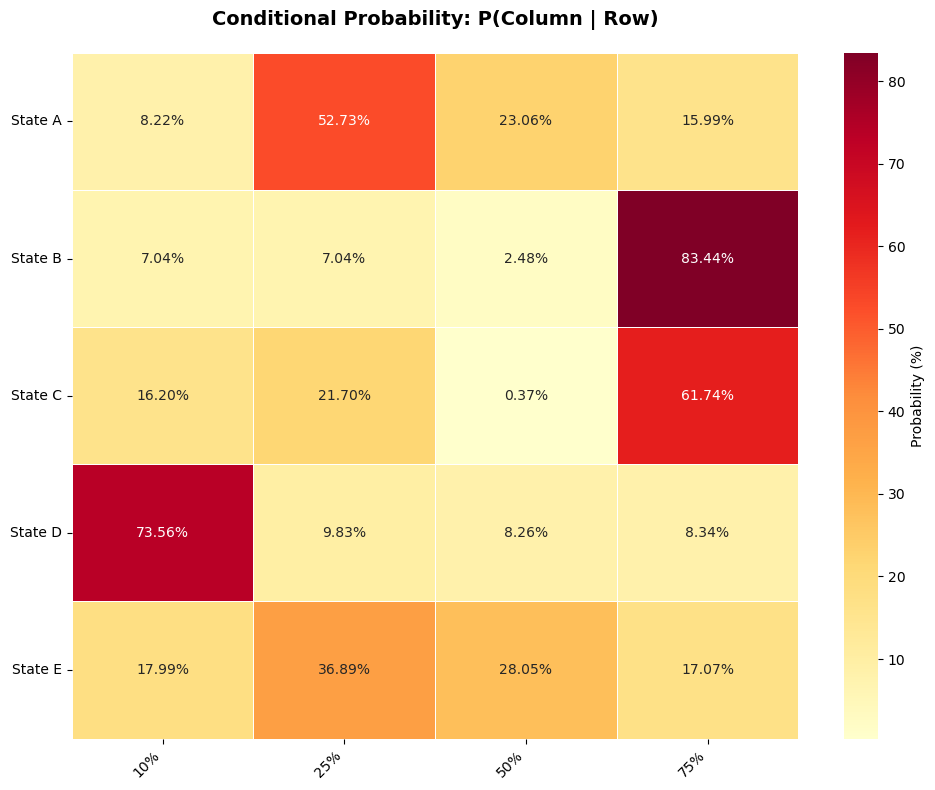

In [44]:

# Sample conditional probability data (5x4 example)
np.random.seed(42)
sample_data = np.random.dirichlet(np.ones(4), size=5)

# Labels
x_labels = ['10%', '25%', '50%', '75%']
y_labels = ['State A', 'State B', 'State C', 'State D', 'State E']

# Seaborn version
fig_sns, ax_sns = heatmap_seaborn(
    data=sample_data,
    x_labels=x_labels,
    y_labels=y_labels,
    title='Conditional Probability: P(Column | Row)',
    decimals=2,
    figsize=(10, 8)
)
plt.show()

# Plotly version
fig_plotly = heatmap_plotly(
    data=sample_data,
    x_labels=x_labels,
    y_labels=y_labels,
    title='Conditional Probability: P(Column | Row)',
    decimals=2,
    width=900,
    height=700
)
fig_plotly.show()

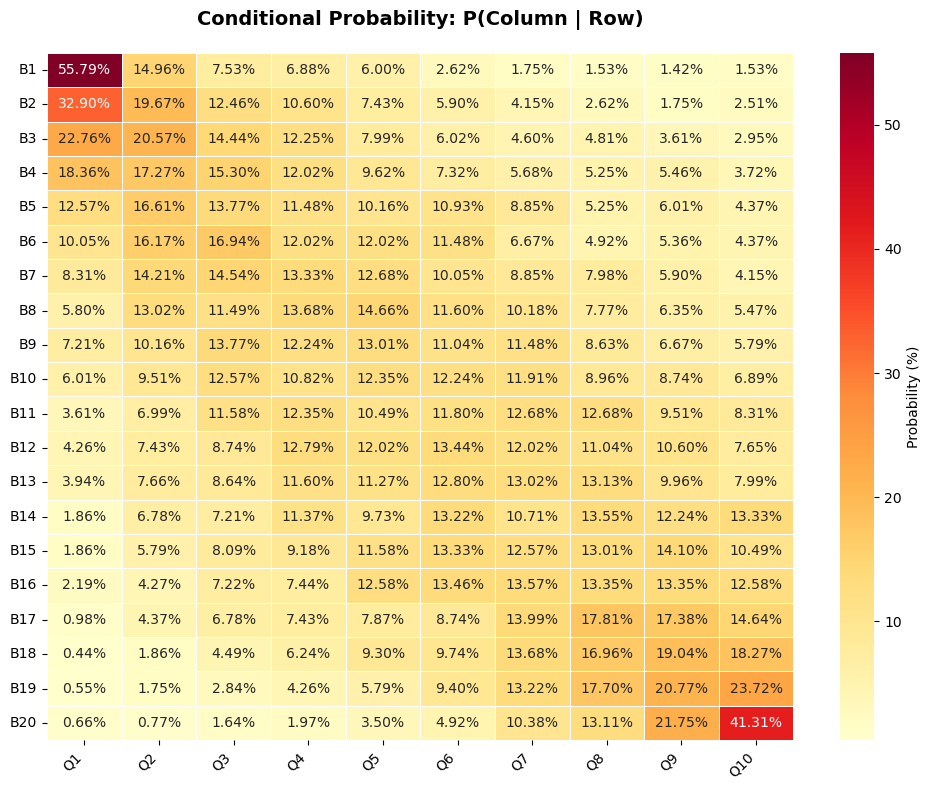

In [45]:

# Labels

x_labels = forward_cols #['10%', '25%', '50%', '75%'] 20
y_labels = forward_rows#['State A', 'State B', 'State C', 'State D', 'State E']

# Seaborn version
fig_sns, ax_sns = heatmap_seaborn(
    data=forward_matrix,
    x_labels=x_labels,
    y_labels=y_labels,
    title='Conditional Probability: P(Column | Row)',
    decimals=2,
    figsize=(10, 8)
)
plt.show()

# Plotly version
fig_plotly = heatmap_plotly(
    data=forward_matrix,
    x_labels=x_labels,
    y_labels=y_labels,
    title='Conditional Probability: P(Column | Row)',
    decimals=2,
    width=900,
    height=700
)
fig_plotly.show()

### Custom Bin Sizes / Labels

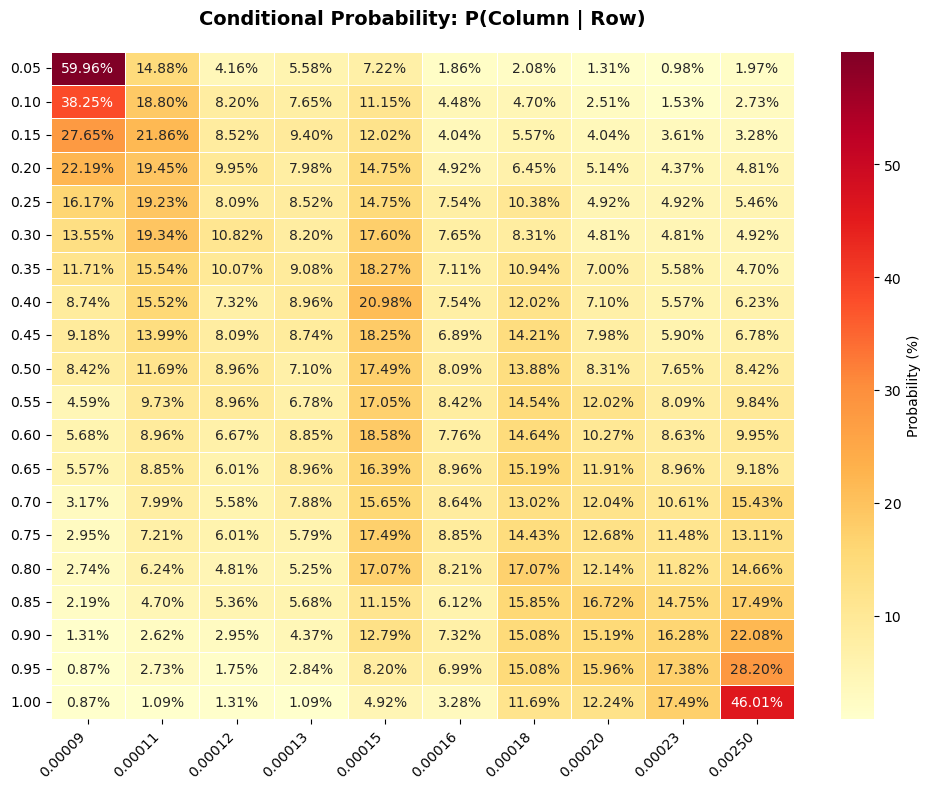

In [54]:

# Labels

x_labels = forward_cols2 #['10%', '25%', '50%', '75%'] 20
y_labels = forward_rows2 #['State A', 'State B', 'State C', 'State D', 'State E']

# Seaborn version
fig_sns, ax_sns = heatmap_seaborn(
    data=forward_matrix2,
    x_labels=x_labels,
    y_labels=y_labels,
    title='Conditional Probability: P(Column | Row)',
    decimals=2,
    figsize=(10, 8)
)
plt.show()

# Plotly version
fig_plotly2 = heatmap_plotly(
    data=forward_matrix2,
    x_labels=x_labels,
    y_labels=y_labels,
    title='Conditional Probability of a Log Return given a VPIN Percentile:  ( Log_Return | VPIN )',
    x_axis_title="Log Returns",
    y_axis_title="VPIN Percentile",
    decimals=2,
    width=1100,
    height=800
)

fig_plotly2.show()

### Intermediate Probability / Streaks Logic

In [47]:
test = metric_from_artificial_buckets.collect()

In [48]:
streak_column = "ecdf__normalized__passive_imbalance_abs"

streaks = metric_from_artificial_buckets.with_columns([

    pl.when(pl.col(streak_column) >= pl.col(streak_column).shift(1))
      .then(pl.lit(1))
      .otherwise(pl.lit(0))
      .fill_null(0)
      .cum_sum()
      .over(
          (pl.col(streak_column) < pl.col(streak_column).shift(1)).fill_null(False).cum_sum()
      )
      .alias("streak")

])

streaks_filtered = streaks.filter(pl.col("streak") >= 2)

In [49]:

# [ X AXIS ]

five_percentiles_decimal = pl.DataFrame({
    "bin": ["0.05", "0.10", "0.15", "0.20", "0.25", "0.30", "0.35", "0.40", "0.45", "0.50",
        "0.55", "0.60", "0.65", "0.70", "0.75", "0.80", "0.85", "0.90", "0.95", "1.00"],
    "bin_min": [i * 0.05 for i in range(20)],
    "bin_max": [i * 0.05 for i in range(1, 21)]
})

five_percentiles_integer = pl.DataFrame({
    "bin": [5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
            55, 60, 65, 70, 75, 80, 85, 90, 95, 100],
    "bin_min": [i * 0.05 for i in range(20)],
    "bin_max": [i * 0.05 for i in range(1, 21)]
})


# [ Y AXIS ]

rounded_log_returns = pl.DataFrame({
    "bin": ["0.00009", "0.00011", "0.00012", "0.00013", "0.00015", 
            "0.00016", "0.00018", "0.00020", "0.00023", "0.00250"],
    "bin_min": [0.00000, 0.00009, 0.00011, 0.00012, 0.00013,
                0.00015, 0.00016, 0.00018, 0.00020, 0.00023],
    "bin_max": [0.00009, 0.00011, 0.00012, 0.00013, 0.00015,
                0.00016, 0.00018, 0.00020, 0.00023, 0.00250]
})


"""
Complete end-to-end example of conditional probability analysis.
"""
print("=" * 80)
print("COMPLETE CONDITIONAL PROBABILITY ANALYSIS")
print("=" * 80)

df = with_streaks__metric_from_artificial_buckets.collect() #!!!
custom_x_column = "streak__ecdf__normalized__passive_imbalance_abs_above_08"
custom_y_column = "delta_passive_midprice_log_std"

# Step 2: Create bins (automatic)
print("\nStep 2: Create bins")
x_bins3 = five_percentiles_decimal # Auto: create_automatic_bins(df, x_column, n_bins=30)
y_bins3 = rounded_log_returns # Auto: create_automatic_bins(df, y_column, n_bins=10)
print("✓ X bins (quintiles):")
print(x_bins3)
print("✓ Y bins (quintiles):")
print(y_bins3)

# Step 3: Calculate forward conditional
print("\nStep 3: Calculate P(Y_i | X_{i-1})")
forward_probs3 = calculate_forward_conditional(df, custom_x_column, custom_y_column, x_bins3, y_bins3)
verify_conditional_probabilities(forward_probs, prob_type="forward")

# Step 4: Calculate reverse conditional
print("\nStep 4: Calculate P(X_{i-1} | Y_i)")
reverse_probs3 = calculate_reverse_conditional(df, custom_x_column, custom_y_column, x_bins3, y_bins3)
verify_conditional_probabilities(reverse_probs, prob_type="reverse")

# Step 5: Create matrices
print("\nStep 5: Create matrices")
forward_matrix3, forward_rows3, forward_cols3 = create_conditional_matrix(
    forward_probs3, x_bins3, y_bins3, prob_type="forward"
)
reverse_matrix3, reverse_rows3, reverse_cols3 = create_conditional_matrix(
    reverse_probs3, x_bins3, y_bins3, prob_type="reverse"
)
print("✓ Matrices created")

# Step 6: Print matrices
print_conditional_matrix(forward_matrix3, forward_rows3, forward_cols3, 
                        "Forward: P(Y_i | X_{i-1})")
print_conditional_matrix(reverse_matrix3, reverse_rows3, reverse_cols3,
                        "Reverse: P(X_{i-1} | Y_i)")


COMPLETE CONDITIONAL PROBABILITY ANALYSIS

Step 2: Create bins
✓ X bins (quintiles):
shape: (20, 3)
┌──────┬─────────┬─────────┐
│ bin  ┆ bin_min ┆ bin_max │
│ ---  ┆ ---     ┆ ---     │
│ str  ┆ f64     ┆ f64     │
╞══════╪═════════╪═════════╡
│ 0.05 ┆ 0.0     ┆ 0.05    │
│ 0.10 ┆ 0.05    ┆ 0.1     │
│ 0.15 ┆ 0.1     ┆ 0.15    │
│ 0.20 ┆ 0.15    ┆ 0.2     │
│ 0.25 ┆ 0.2     ┆ 0.25    │
│ 0.30 ┆ 0.25    ┆ 0.3     │
│ 0.35 ┆ 0.3     ┆ 0.35    │
│ 0.40 ┆ 0.35    ┆ 0.4     │
│ 0.45 ┆ 0.4     ┆ 0.45    │
│ 0.50 ┆ 0.45    ┆ 0.5     │
│ 0.55 ┆ 0.5     ┆ 0.55    │
│ 0.60 ┆ 0.55    ┆ 0.6     │
│ 0.65 ┆ 0.6     ┆ 0.65    │
│ 0.70 ┆ 0.65    ┆ 0.7     │
│ 0.75 ┆ 0.7     ┆ 0.75    │
│ 0.80 ┆ 0.75    ┆ 0.8     │
│ 0.85 ┆ 0.8     ┆ 0.85    │
│ 0.90 ┆ 0.85    ┆ 0.9     │
│ 0.95 ┆ 0.9     ┆ 0.95    │
│ 1.00 ┆ 0.95    ┆ 1.0     │
└──────┴─────────┴─────────┘
✓ Y bins (quintiles):
shape: (10, 3)
┌─────────┬─────────┬─────────┐
│ bin     ┆ bin_min ┆ bin_max │
│ ---     ┆ ---     ┆ ---     │
│ str     ┆ f

### Streak Heatmap

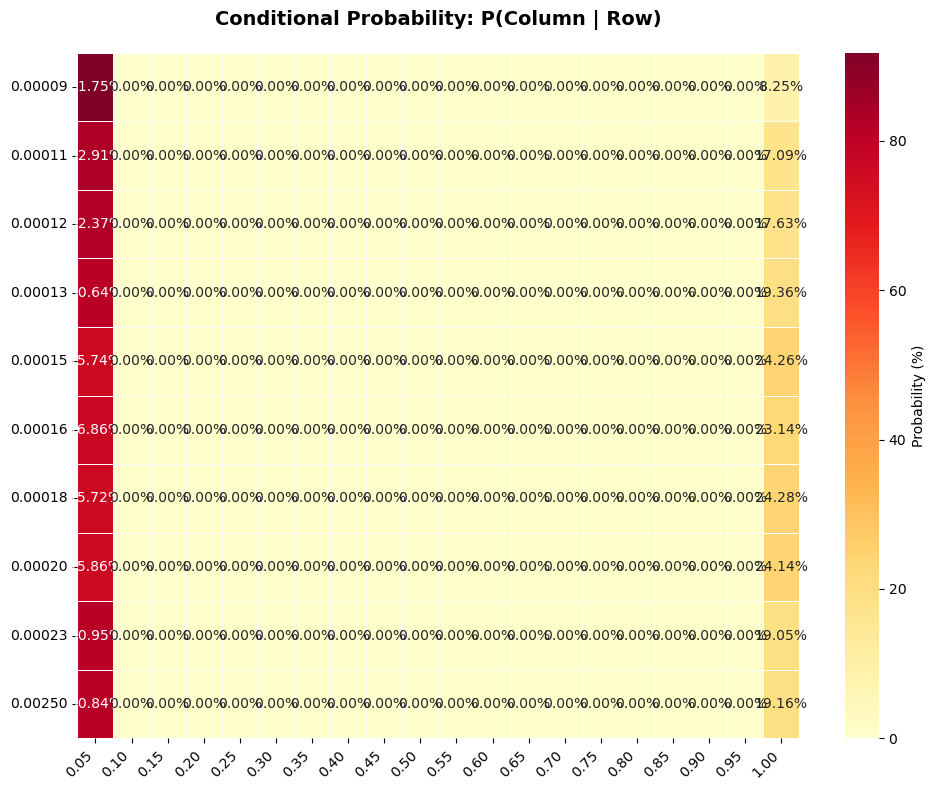

In [50]:

# Labels

x_labels = reverse_cols3 #['10%', '25%', '50%', '75%'] 20
y_labels = reverse_rows3 #['State A', 'State B', 'State C', 'State D', 'State E']

# Seaborn version
fig_sns, ax_sns = heatmap_seaborn(
    data=reverse_matrix3,
    x_labels=x_labels,
    y_labels=y_labels,
    title='Conditional Probability: P(Column | Row)',
    decimals=2,
    figsize=(10, 8)
)
plt.show()

# Plotly version
fig_plotly2 = heatmap_plotly(
    data=reverse_matrix3,
    x_labels=x_labels,
    y_labels=y_labels,
    title='Conditional Probability: P(Column | Row)',
    x_axis_title="Log Returns",
    y_axis_title="VPIN Percentile",
    decimals=2,
    width=1200,
    height=700
)

fig_plotly2.show()